<a href="https://colab.research.google.com/github/richards-okiemute/well-clustering-with-kmeans-and-ac/blob/main/WellX_Well_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WellX Clustering using K-Means Algorithm


This project is demonstrates the utilization of clustering algorithms (K-Means and Agglomerative Clustering) for the precise classification of lithologies within Nigeria's Niger Delta region.

Prior to delving into the clustering algorithms, an extensive phase of data exploration was initiated. This preliminary step aimed to unravel the intricacies of the individual variables constituting the dataset.

The focal point of this endeavor lies in the employment of unsupervised clustering algorithms, majorly K-Means. By leveraging the intrinsic patterns within the dataset, K-Means facilitates the segregation of data points into cohesive clusters, thereby revealing distinctive lithological classifications.


In [28]:
import numpy as np #numerical calcuation
import pandas as pd #data manipulation
import matplotlib.pyplot as plt #data visualization
import matplotlib.cm as cm
import seaborn as sns #data visualization
import sklearn #ML trainoing and prediction
import scipy.cluster.hierarchy as hc
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12,5)
sns.set_context('paper')
import scipy
import scipy.stats as stats
import pylab

In [87]:
# Mount Drive folder '/content/drive' to allow Colab access to the well data file.
from google.colab import drive
drive.mount('/content/drive') #this will require permission to access mounted folder
well_file = pd.read_csv("/content/drive/MyDrive/My Datasets/pologbene_well02.csv", sep ='\t')
well_file.head(21)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,~WELL,INFORMATION,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,#---------------------------------------------...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,STRT,.FT,600,:START,DEPTH,NaN,NaN,NaN,NaN,NaN
2,STOP,.FT,5039.5,:STOP,DEPTH,NaN,NaN,NaN,NaN,NaN
3,STEP,.FT,0.5,:STEP,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,.,-999.25,:NULL,VALUE,NaN,NaN,NaN,NaN,NaN
5,COMP,.,CHEVRON,NIGERIAN,LTD,:COMPANY,NaN,NaN,NaN,NaN
6,WELL,.,TOMBOY_plan,:WELL,NaN,NaN,NaN,NaN,NaN,NaN
7,FLD,.,Tomboy,:FIELD,NaN,NaN,NaN,NaN,NaN,NaN
8,LOC,.,POLOGBENE(01),:LOCATION,NaN,NaN,NaN,NaN,NaN,NaN
9,STAT,.,UNKNOWN,:STATE,NaN,NaN,NaN,NaN,NaN,NaN


**WELL INFORMATION**
* **Company:** Chevron Nigerian Limited
* **Country:** Nigeria
* **Field:** Tomboy
* **Location:** Pologbene(01)
* **Well ID:** TM0001_plan
* **Servicing Compnay:** Unknown

In [30]:
well_file1 = well_file[22:]

In [31]:
well_file1.head(2)

,~WELL,INFORMATION,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
22,NaN,MD(ft),CALI,GR(API),LITH,LLS,SP,RHOB(g/cc),LLD,ITT(usec/ft)
23,NaN,600,-999.25,16.505,5139,7.874,337.457,2.159,19.763,139.912


In [32]:
well_file1.columns = well_file1.iloc[0]

well_file1 = well_file1[1:]

well_file1.head()

22,NaN,MD(ft),CALI,GR(API),LITH,LLS,SP,RHOB(g/cc),LLD,ITT(usec/ft)
23,NaN,600,-999.25,16.505,5139,7.874,337.457,2.159,19.763,139.912
24,NaN,600.5,-999.25,17.685,5139,7.892,337.457,2.157,19.056,140.616
25,NaN,601,-999.25,18.962,5139,7.785,337.457,2.159,18.729,140.732
26,NaN,601.5,-999.25,19.122,5139,7.713,339.777,2.16,19.208,140.92
27,NaN,602,-999.25,18.014,5139,7.691,343.256,2.162,20.818,142.288


In [33]:
well_file1.columns

Index([           nan,       'MD(ft)',         'CALI',      'GR(API)',
               'LITH',          'LLS',           'SP',   'RHOB(g/cc)',
                'LLD', 'ITT(usec/ft)'],
      dtype='object', name=22)

In [34]:
well_file1 = well_file1.dropna(axis = 1).reset_index(drop=True)
well_file1.head()

22,MD(ft),CALI,GR(API),LITH,LLS,SP,RHOB(g/cc),LLD,ITT(usec/ft)
0,600,-999.25,16.505,5139,7.874,337.457,2.159,19.763,139.912
1,600.5,-999.25,17.685,5139,7.892,337.457,2.157,19.056,140.616
2,601,-999.25,18.962,5139,7.785,337.457,2.159,18.729,140.732
3,601.5,-999.25,19.122,5139,7.713,339.777,2.16,19.208,140.92
4,602,-999.25,18.014,5139,7.691,343.256,2.162,20.818,142.288


In [35]:
well_file1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8880 entries, 0 to 8879
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   MD(ft)        8880 non-null   object
 1   CALI          8880 non-null   object
 2   GR(API)       8880 non-null   object
 3   LITH          8880 non-null   object
 4   LLS           8880 non-null   object
 5   SP            8880 non-null   object
 6   RHOB(g/cc)    8880 non-null   object
 7   LLD           8880 non-null   object
 8   ITT(usec/ft)  8880 non-null   object
dtypes: object(9)
memory usage: 624.5+ KB


In [36]:
well_file1.columns

Index(['MD(ft)', 'CALI', 'GR(API)', 'LITH', 'LLS', 'SP', 'RHOB(g/cc)', 'LLD',
       'ITT(usec/ft)'],
      dtype='object', name=22)

In [37]:
wellX = well_file1.copy()

In [38]:
columns = ['MD(ft)', 'CALI', 'GR(API)', 'LLS', 'SP', 'RHOB(g/cc)', 'LLD','ITT(usec/ft)']
for i in columns:
  wellX[i] = wellX[i].astype('float64')
wellX['LITH'] = wellX['LITH'].astype('category')

In [39]:
wellX['LITH'].unique()

['5139', '5138.0977', '5138', '5138.9023']
Categories (4, object): ['5138', '5138.0977', '5138.9023', '5139']

In [40]:
wellX.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8880 entries, 0 to 8879
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   MD(ft)        8880 non-null   float64 
 1   CALI          8880 non-null   float64 
 2   GR(API)       8880 non-null   float64 
 3   LITH          8880 non-null   category
 4   LLS           8880 non-null   float64 
 5   SP            8880 non-null   float64 
 6   RHOB(g/cc)    8880 non-null   float64 
 7   LLD           8880 non-null   float64 
 8   ITT(usec/ft)  8880 non-null   float64 
dtypes: category(1), float64(8)
memory usage: 564.0 KB


In [41]:
wellX.head()

22,MD(ft),CALI,GR(API),LITH,LLS,SP,RHOB(g/cc),LLD,ITT(usec/ft)
0,600.0,-999.25,16.505,5139,7.874,337.457,2.159,19.763,139.912
1,600.5,-999.25,17.685,5139,7.892,337.457,2.157,19.056,140.616
2,601.0,-999.25,18.962,5139,7.785,337.457,2.159,18.729,140.732
3,601.5,-999.25,19.122,5139,7.713,339.777,2.160,19.208,140.920
4,602.0,-999.25,18.014,5139,7.691,343.256,2.162,20.818,142.288


### **Initial Data Profiling and Statistical Summary**

* **Measured Depth (MD):** The wellbore profile stretches from **600 ft down to 5,039.5 ft**, capturing a continuous vertical sequence of Niger Delta sediments.
* **Data Density:** With **8,880 samples** spaced at 0.5 ft intervals, the dataset offers a high-resolution window into the reservoir's lithological variations.
* **Statistical Anomalies:**
  * The **Caliper Log (CALI)** exhibits a minimum value of `-999.25` (the standard LAS file null value placeholder), resulting in an artificial mean of `-782.08` and high standard deviation. This indicates missing sensor readings or uncalibrated intervals that must be handled or ignored in geometric studies, but can be scaled for clustering if treated as unique numeric flags.

In [42]:
round(wellX.describe(),3)

22,MD(ft),CALI,GR(API),LLS,SP,RHOB(g/cc),LLD,ITT(usec/ft)
count,8880.000,8880.000,8880.000,8880.000,8880.000,8880.000,8880.000,8880.000
mean,2819.750,-782.081,20.625,41.909,183.201,2.135,70.941,132.392
std,1281.790,416.548,12.079,44.715,159.189,0.056,38.444,6.550
min,600.000,-999.250,9.245,0.000,15.166,1.878,4.599,109.364
25%,1709.875,-999.250,14.844,4.808,48.018,2.099,37.726,127.992
50%,2819.750,-999.250,17.109,16.127,87.816,2.133,76.940,132.768
75%,3929.625,-999.250,20.041,80.033,347.006,2.168,99.744,136.984
max,5039.500,22.700,102.896,194.016,999.000,2.563,194.016,158.620


# **Observations**

Well depth (Measured Depth) started from 600ft to 5039.50ft

## **Exploring the dataset**

In [43]:
'''Creating functions for both displots, boxplots, and to describe each
log features'''

def displot(log_feature):
  for i in log_feature:
    plt.figure()
    print('\n')
    sns.distplot(wellX[i])
    plt.xlabel(i,fontweight='bold')
    plt.ylabel('Density', fontweight='bold')
    plt.title(i+' Distribution Plot',fontweight='bold', size=14)


def boxplot(log_feature):
 for i in log_feature:
    plt.figure()
    sns.boxplot(wellX[i], showmeans=True)
    plt.title(i + ' distribution plot',fontweight='bold')
    plt.xlabel(i,fontweight='bold')


def describe(log_feature):
  for i in log_feature:
    print("Description of "+ i)
    describe = wellX[i].describe()
    print(describe,'\n')

# Exploring the Caliber Log, Spontaneous Potential Log,  Lithology Log

In [44]:
wellX['LITH'].unique()

['5139', '5138.0977', '5138', '5138.9023']
Categories (4, object): ['5138', '5138.0977', '5138.9023', '5139']

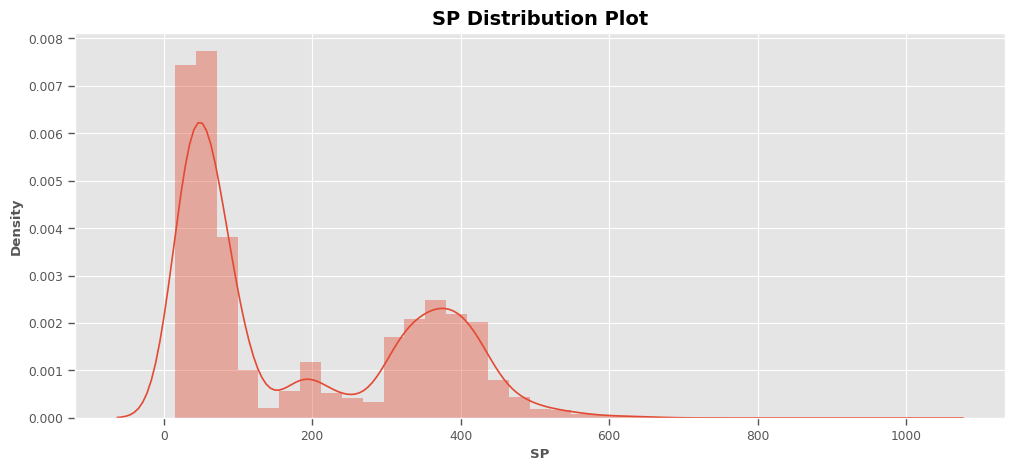

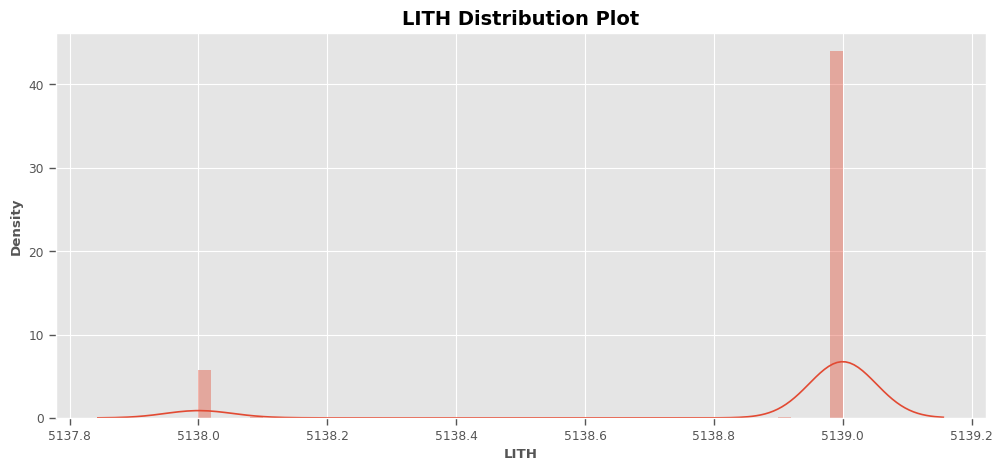

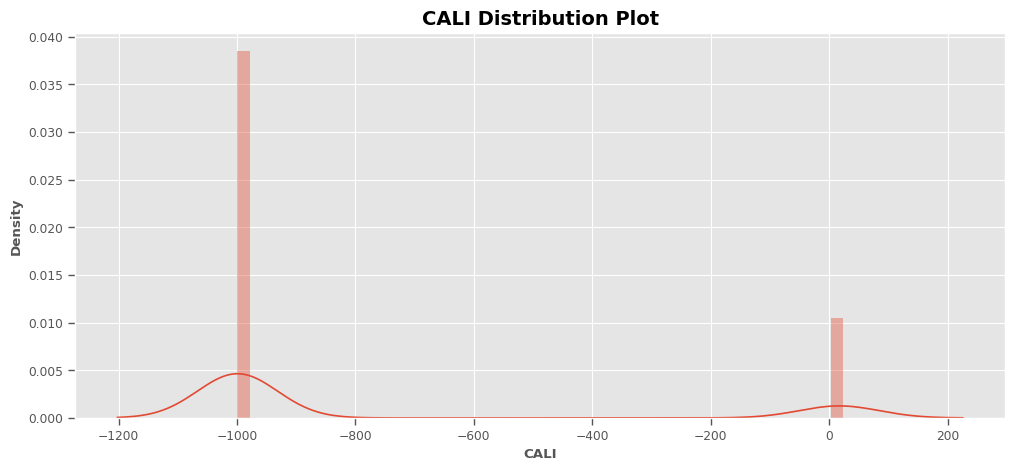

In [45]:
displot(['SP','LITH', 'CALI'])

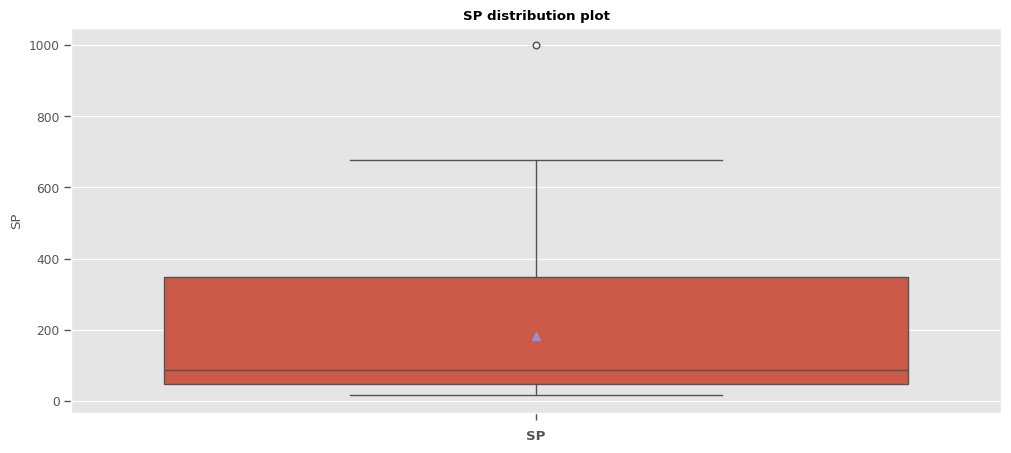

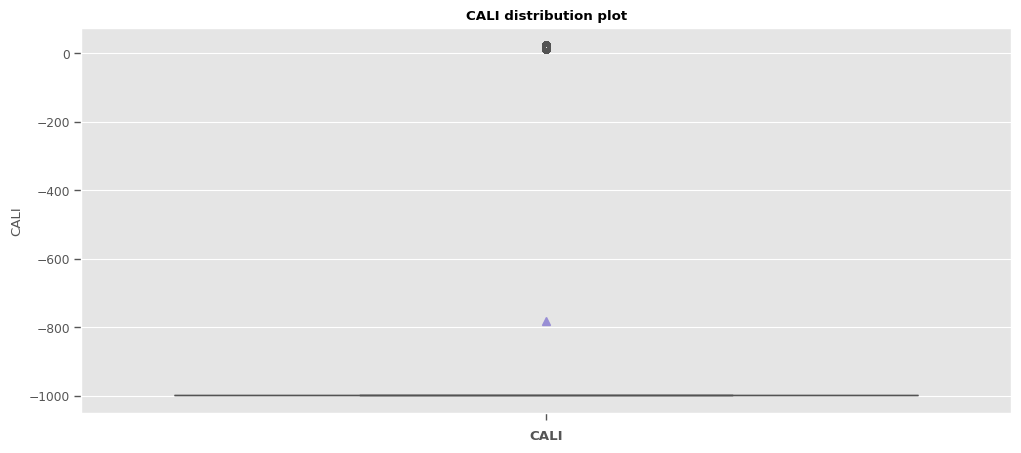

In [46]:
boxplot(['SP', 'CALI'])

### **Interpretations: Caliper, Spontaneous Potential & Baseline Lithology Distribution**

* **Spontaneous Potential (SP):** Displays a bimodal distribution with peaks near low values (shales with no deflection) and high values (clean permeable sands with strong deflection). This clear separation makes SP a strong candidate for fluid and permeability boundary classification.
* **Lithology Code (LITH):** The baseline discrete categorization is highly skewed, with code `5139` occupying over 88% of the data points (`7,812` occurrences). This shows that prior simple lithology classification was highly dominant toward one primary rock class, justifying the need for multidimensional clustering to find subtle, more informative subdivisions.

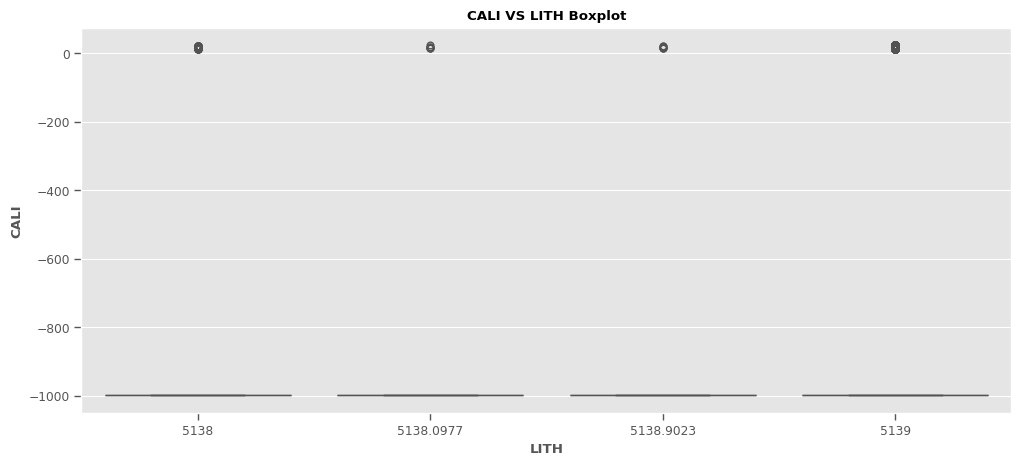

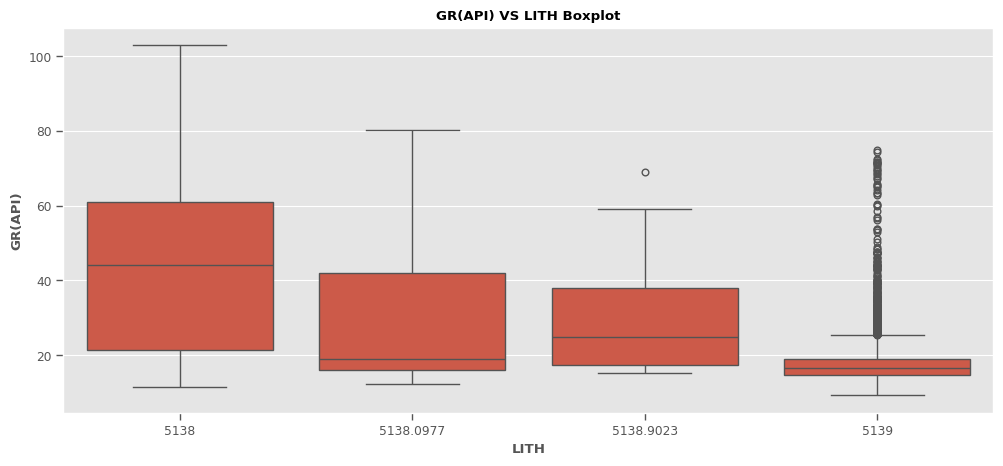

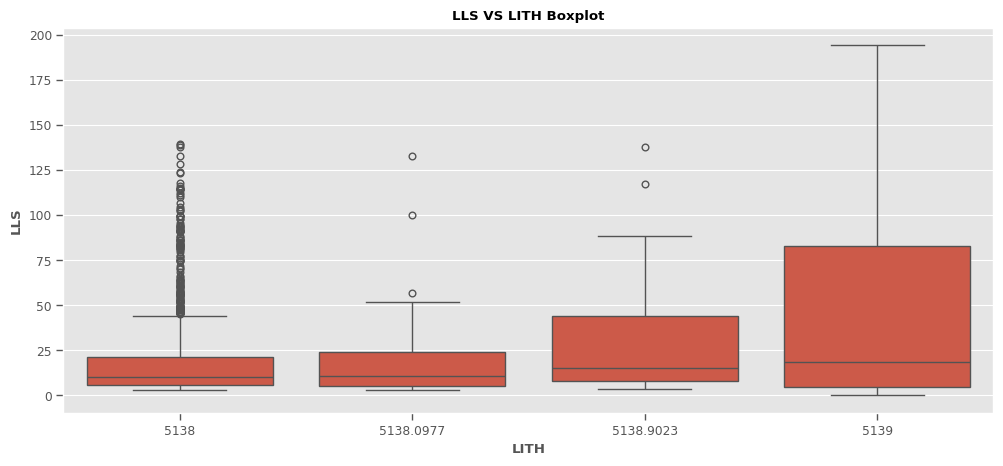

In [47]:
def boxplot_lith(x,y):
      for i in columns[x:y]:
        plt.figure()
        sns.boxplot(data=wellX, y=wellX[i], x=wellX['LITH'], orient='v')
        plt.title(i + ' VS LITH Boxplot',fontweight='bold')
        plt.ylabel(i,fontweight='bold')
        plt.xlabel('LITH',fontweight='bold')

boxplot_lith(1,4)


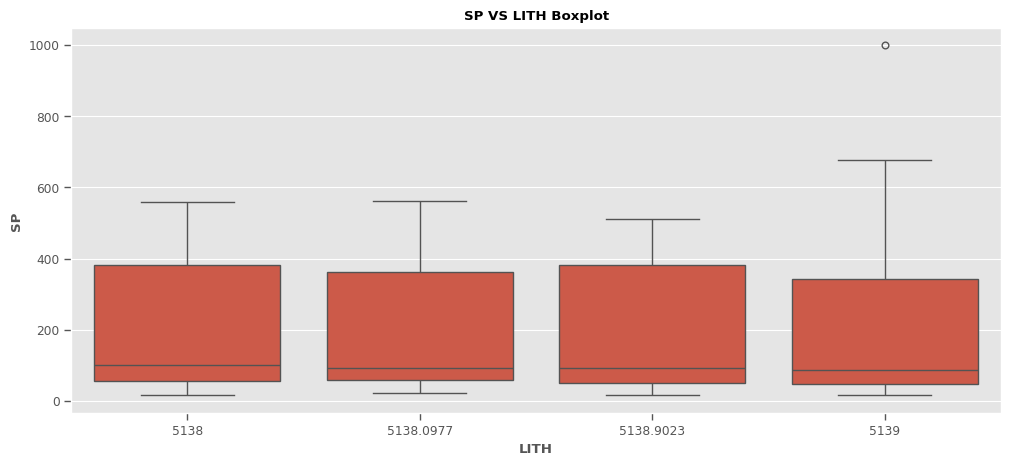

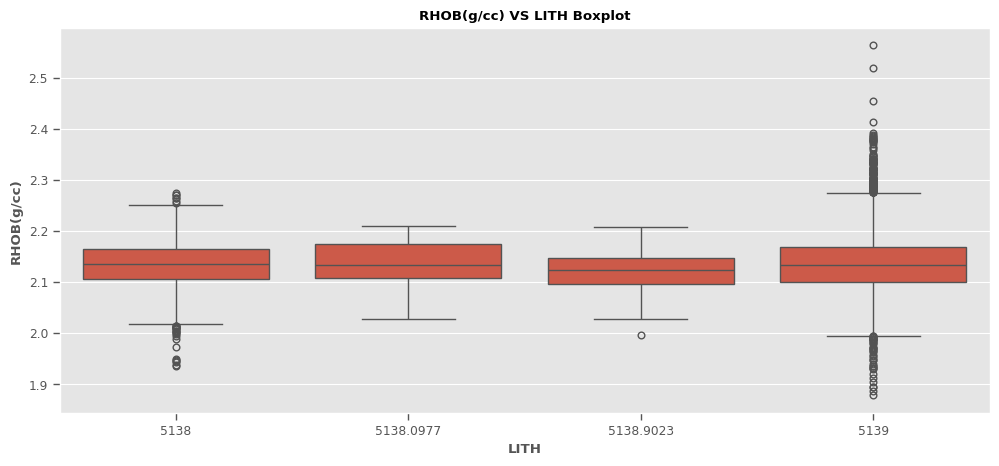

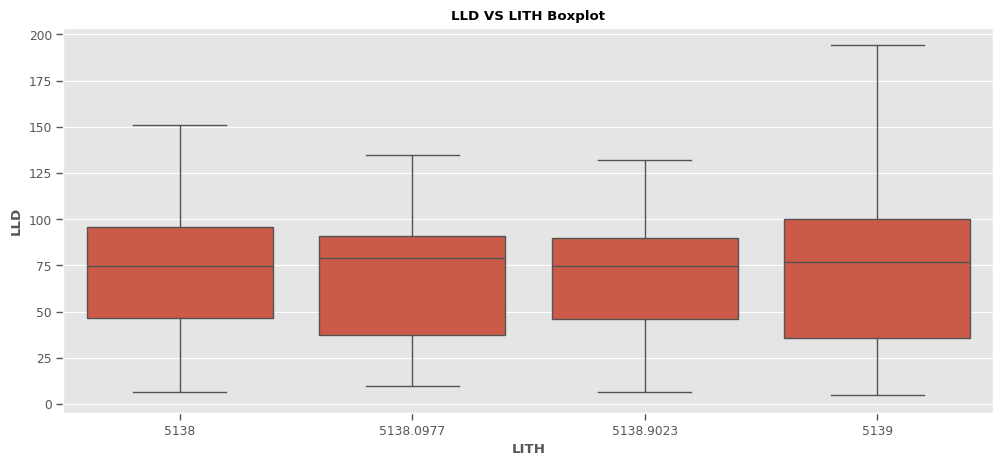

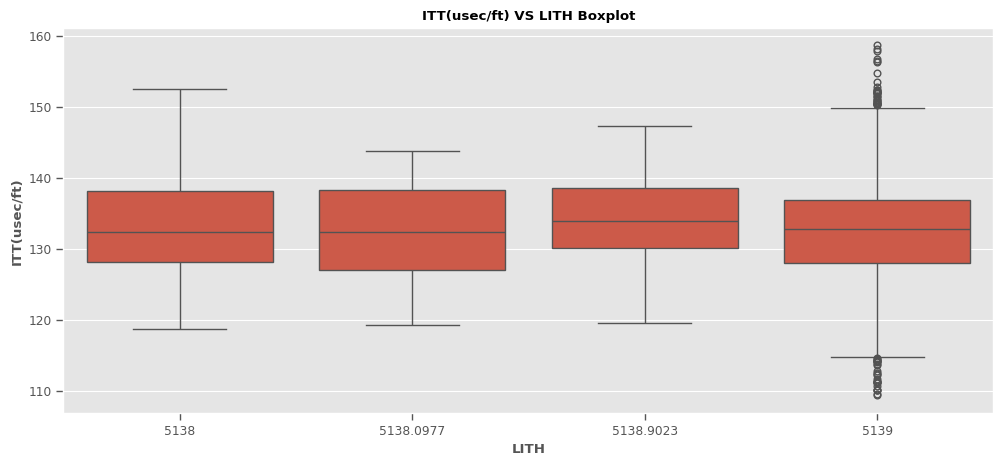

In [48]:
boxplot_lith(4,8)

In [49]:
describe(['SP','LITH', 'CALI'])

Description of SP
count    8880.000000
mean      183.201247
std       159.188607
min        15.166000
25%        48.018000
50%        87.815500
75%       347.006000
max       999.000000
Name: SP, dtype: float64 

Description of LITH
count     8880
unique       4
top       5139
freq      7812
Name: LITH, dtype: object 

Description of CALI
count    8880.000000
mean     -782.081458
std       416.547980
min      -999.250000
25%      -999.250000
50%      -999.250000
75%      -999.250000
max        22.700000
Name: CALI, dtype: float64 



Exploring Gamma Ray Log

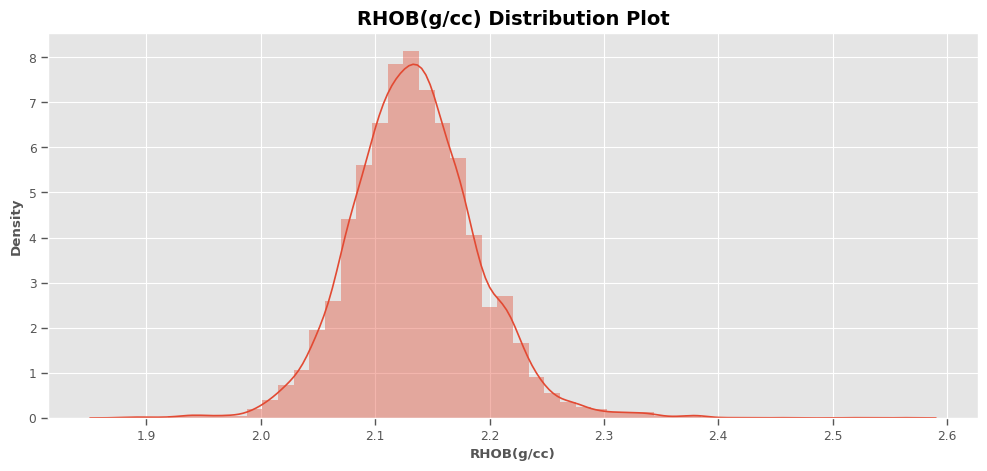

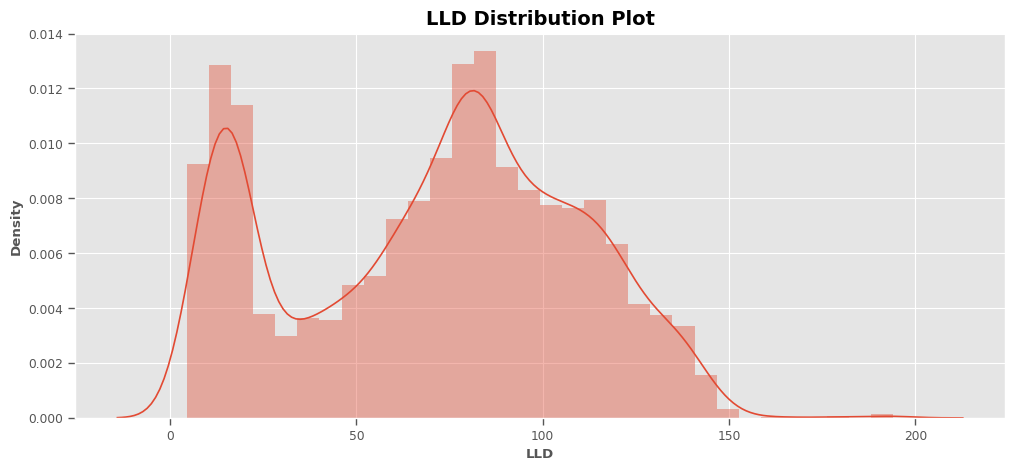

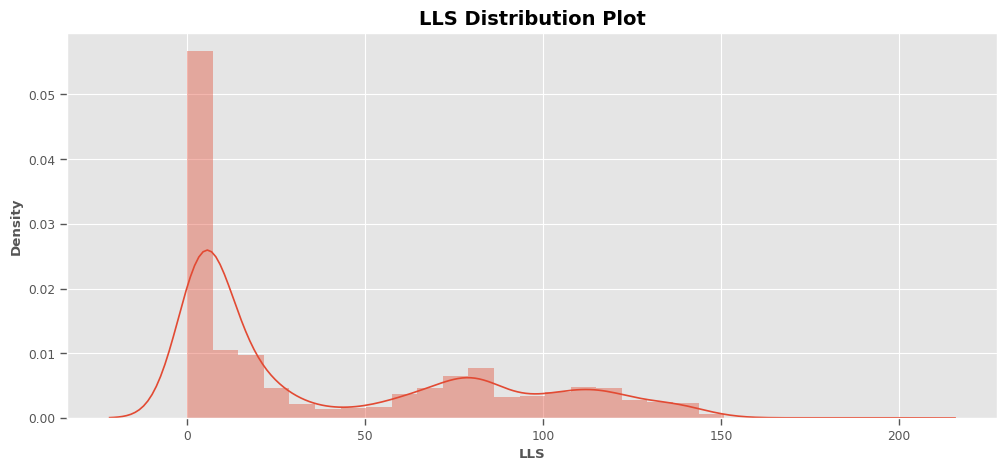

In [50]:
displot(['RHOB(g/cc)', 'LLD','LLS'])

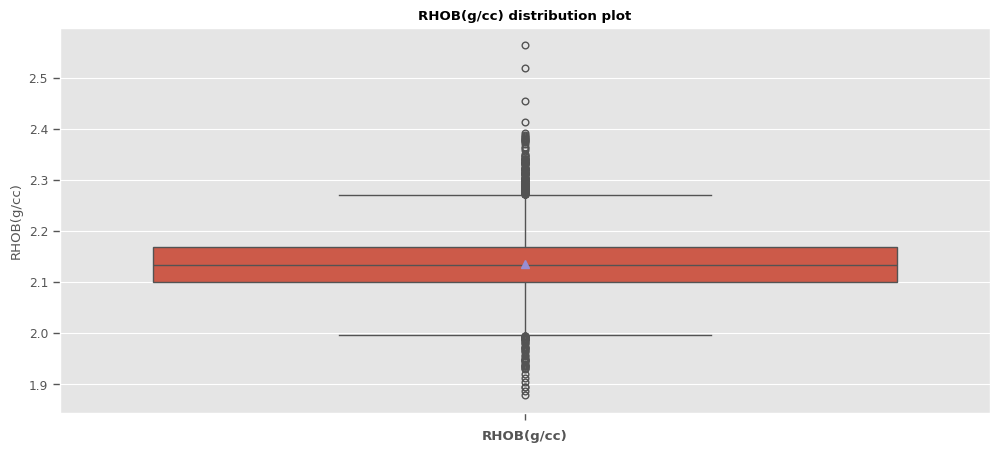

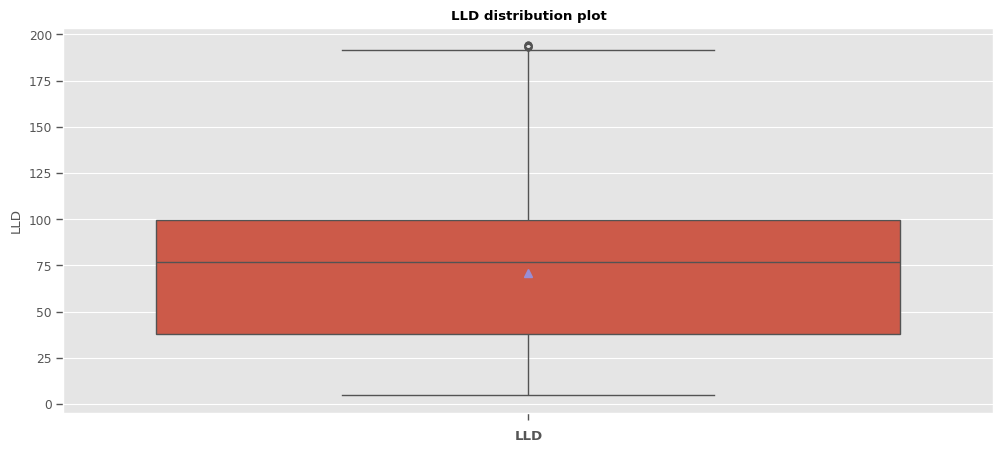

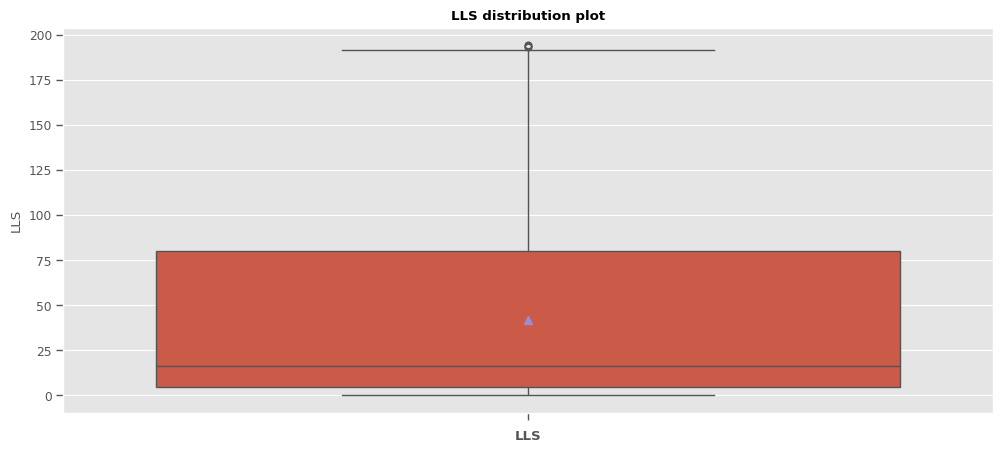

In [51]:
boxplot(['RHOB(g/cc)', 'LLD','LLS'])

In [52]:
describe(['RHOB(g/cc)', 'LLD','LLS'])

Description of RHOB(g/cc)
count    8880.000000
mean        2.135128
std         0.055846
min         1.878000
25%         2.099000
50%         2.133000
75%         2.168000
max         2.563000
Name: RHOB(g/cc), dtype: float64 

Description of LLD
count    8880.000000
mean       70.941440
std        38.443574
min         4.599000
25%        37.726500
50%        76.939500
75%        99.744250
max       194.016000
Name: LLD, dtype: float64 

Description of LLS
count    8880.000000
mean       41.909012
std        44.714960
min         0.000000
25%         4.808500
50%        16.127500
75%        80.032750
max       194.016000
Name: LLS, dtype: float64 



### **Interpretations: Porosity (RHOB) and Resistivity (LLD/LLS) Distributions**

* **Bulk Density (RHOB):** Exhibits a narrow, stable Gaussian-like distribution centered around **2.13 g/cc**. This density range is characteristic of unconsolidated to semi-consolidated tertiary sand-shale sequences typical of the Niger Delta.
* **Resistivity (LLD & LLS):** Both shallow (LLS) and deep (LLD) resistivity curves show similar shapes, indicating excellent tracking of fluid content. The wide spread of values—ranging from less than 5 ohm-m up to 194 ohm-m—highlights alternating sequences of brine-saturated shales (low resistivity) and potentially hydrocarbon-bearing or fresh-water sandstones (high resistivity).

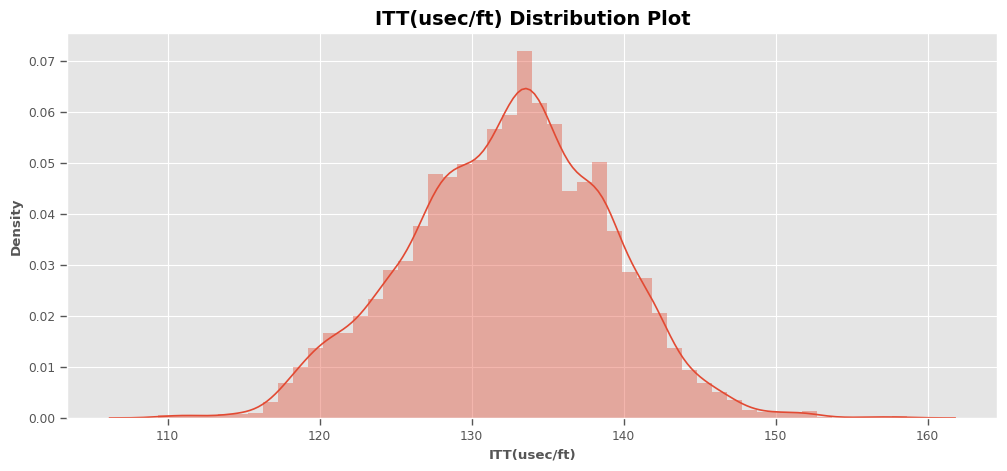

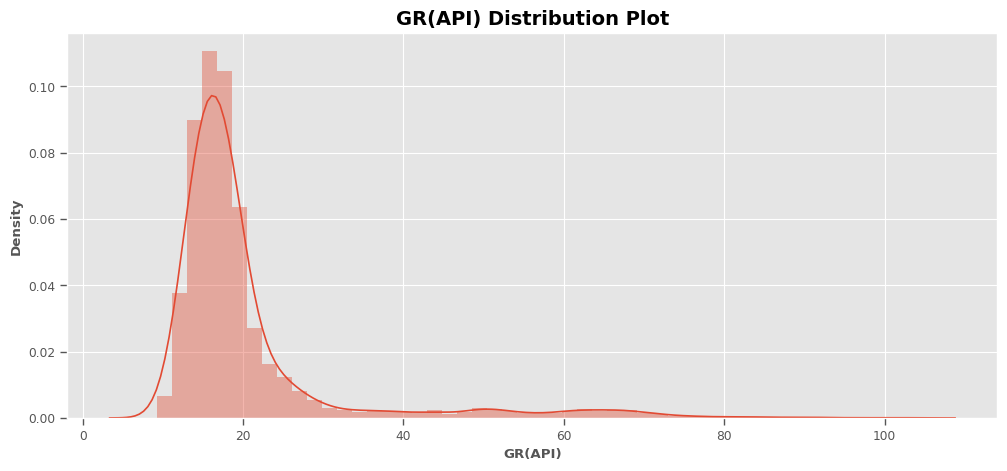

In [53]:
displot(['ITT(usec/ft)','GR(API)'])

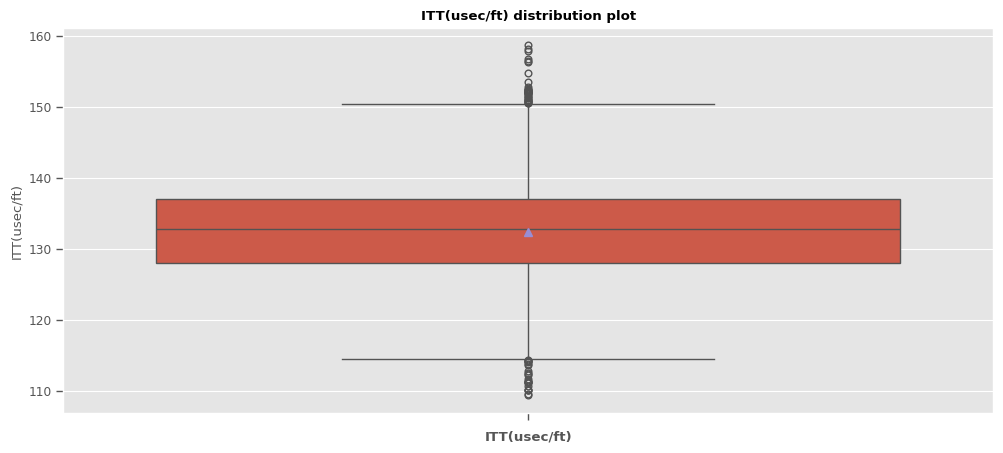

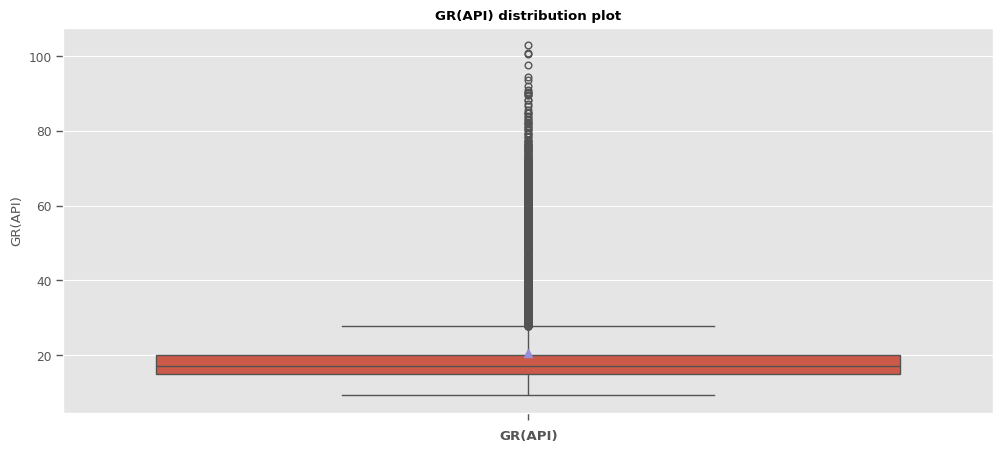

In [54]:
boxplot(['ITT(usec/ft)','GR(API)'])

In [55]:
describe(['ITT(usec/ft)','GR(API)'])

Description of ITT(usec/ft)
count    8880.000000
mean      132.392468
std         6.549505
min       109.364000
25%       127.992000
50%       132.768000
75%       136.984000
max       158.620000
Name: ITT(usec/ft), dtype: float64 

Description of GR(API)
count    8880.000000
mean       20.624897
std        12.079082
min         9.245000
25%        14.844000
50%        17.109000
75%        20.040750
max       102.896000
Name: GR(API), dtype: float64 



### **Interpretations: Acoustic Transit Time (ITT) and Gamma Ray (GR) Distributions**

* **Interval Transit Time (ITT / Sonic):** Centers tightly around **132 μs/ft**, showing a slightly skewed distribution. Higher transit times indicate slower acoustic velocities, which represent high-porosity formations or clay-dominated matrix systems.
* **Gamma Ray (GR):** Shows a sharp concentration around **14-20 API**, with a trailing tail extending up to **102 API**. In Niger Delta sands, low GR indicates clean sands, while the high API tails represent marine shale barriers and clay barriers. The sharp boundary near 20 API indicates that the wellbore is highly sand-dominated.

In [56]:
wellX['LITH'] = wellX['LITH'].astype('float')

<Axes: xlabel='22', ylabel='22'>

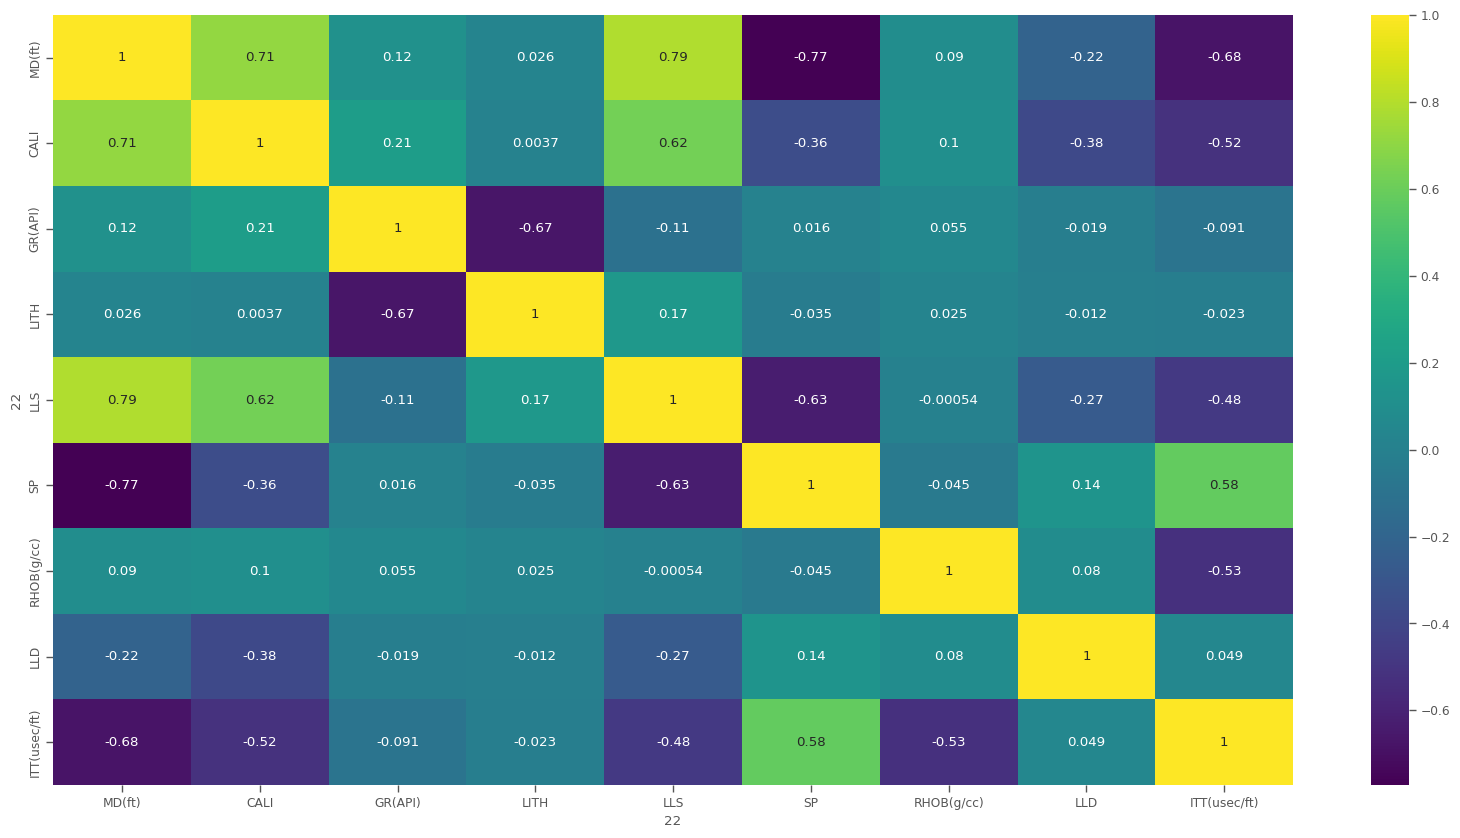

In [57]:
plt.figure(figsize = (20,10))
sns.heatmap(wellX.corr(), annot = True, cmap='viridis')

# **Observations**

As shown above, the correlation map between different variables in the pologbene_well02 dataset shows that:

* There are weak correlations between the variables expect for correlations between:
    * **MD(ft) vs LLS:** There exist a relatively strong correlation (0.79) between the measured depth and the Shallow laterolog.
    * **MD(ft) vs CALI:** There exist a relatively strong correlation (0.69) between the measured depth and the Caliper Log .
    * **CALI vs LLS:** There also exist a moderately positive correlation (0.61) between the Caliper Log and the Shallow Laterolog
    * **GRA(API) vs LITH:** There also exist a moderately negative correlation (-0.67) between the Gamma Ray Log and the Lithology Log.
    * **MD(ft) vs ITT(usec/ft):** There exist a moderately strong negative correlation (-0.68) between the measured depth and the Sonic Log.
    * **RHOB(g/cc) vs ITT(usec/ft):** There exist a moderately negative  correlation (-0.53) between the porosity log and the Sonic Log.

<Figure size 500x500 with 0 Axes>

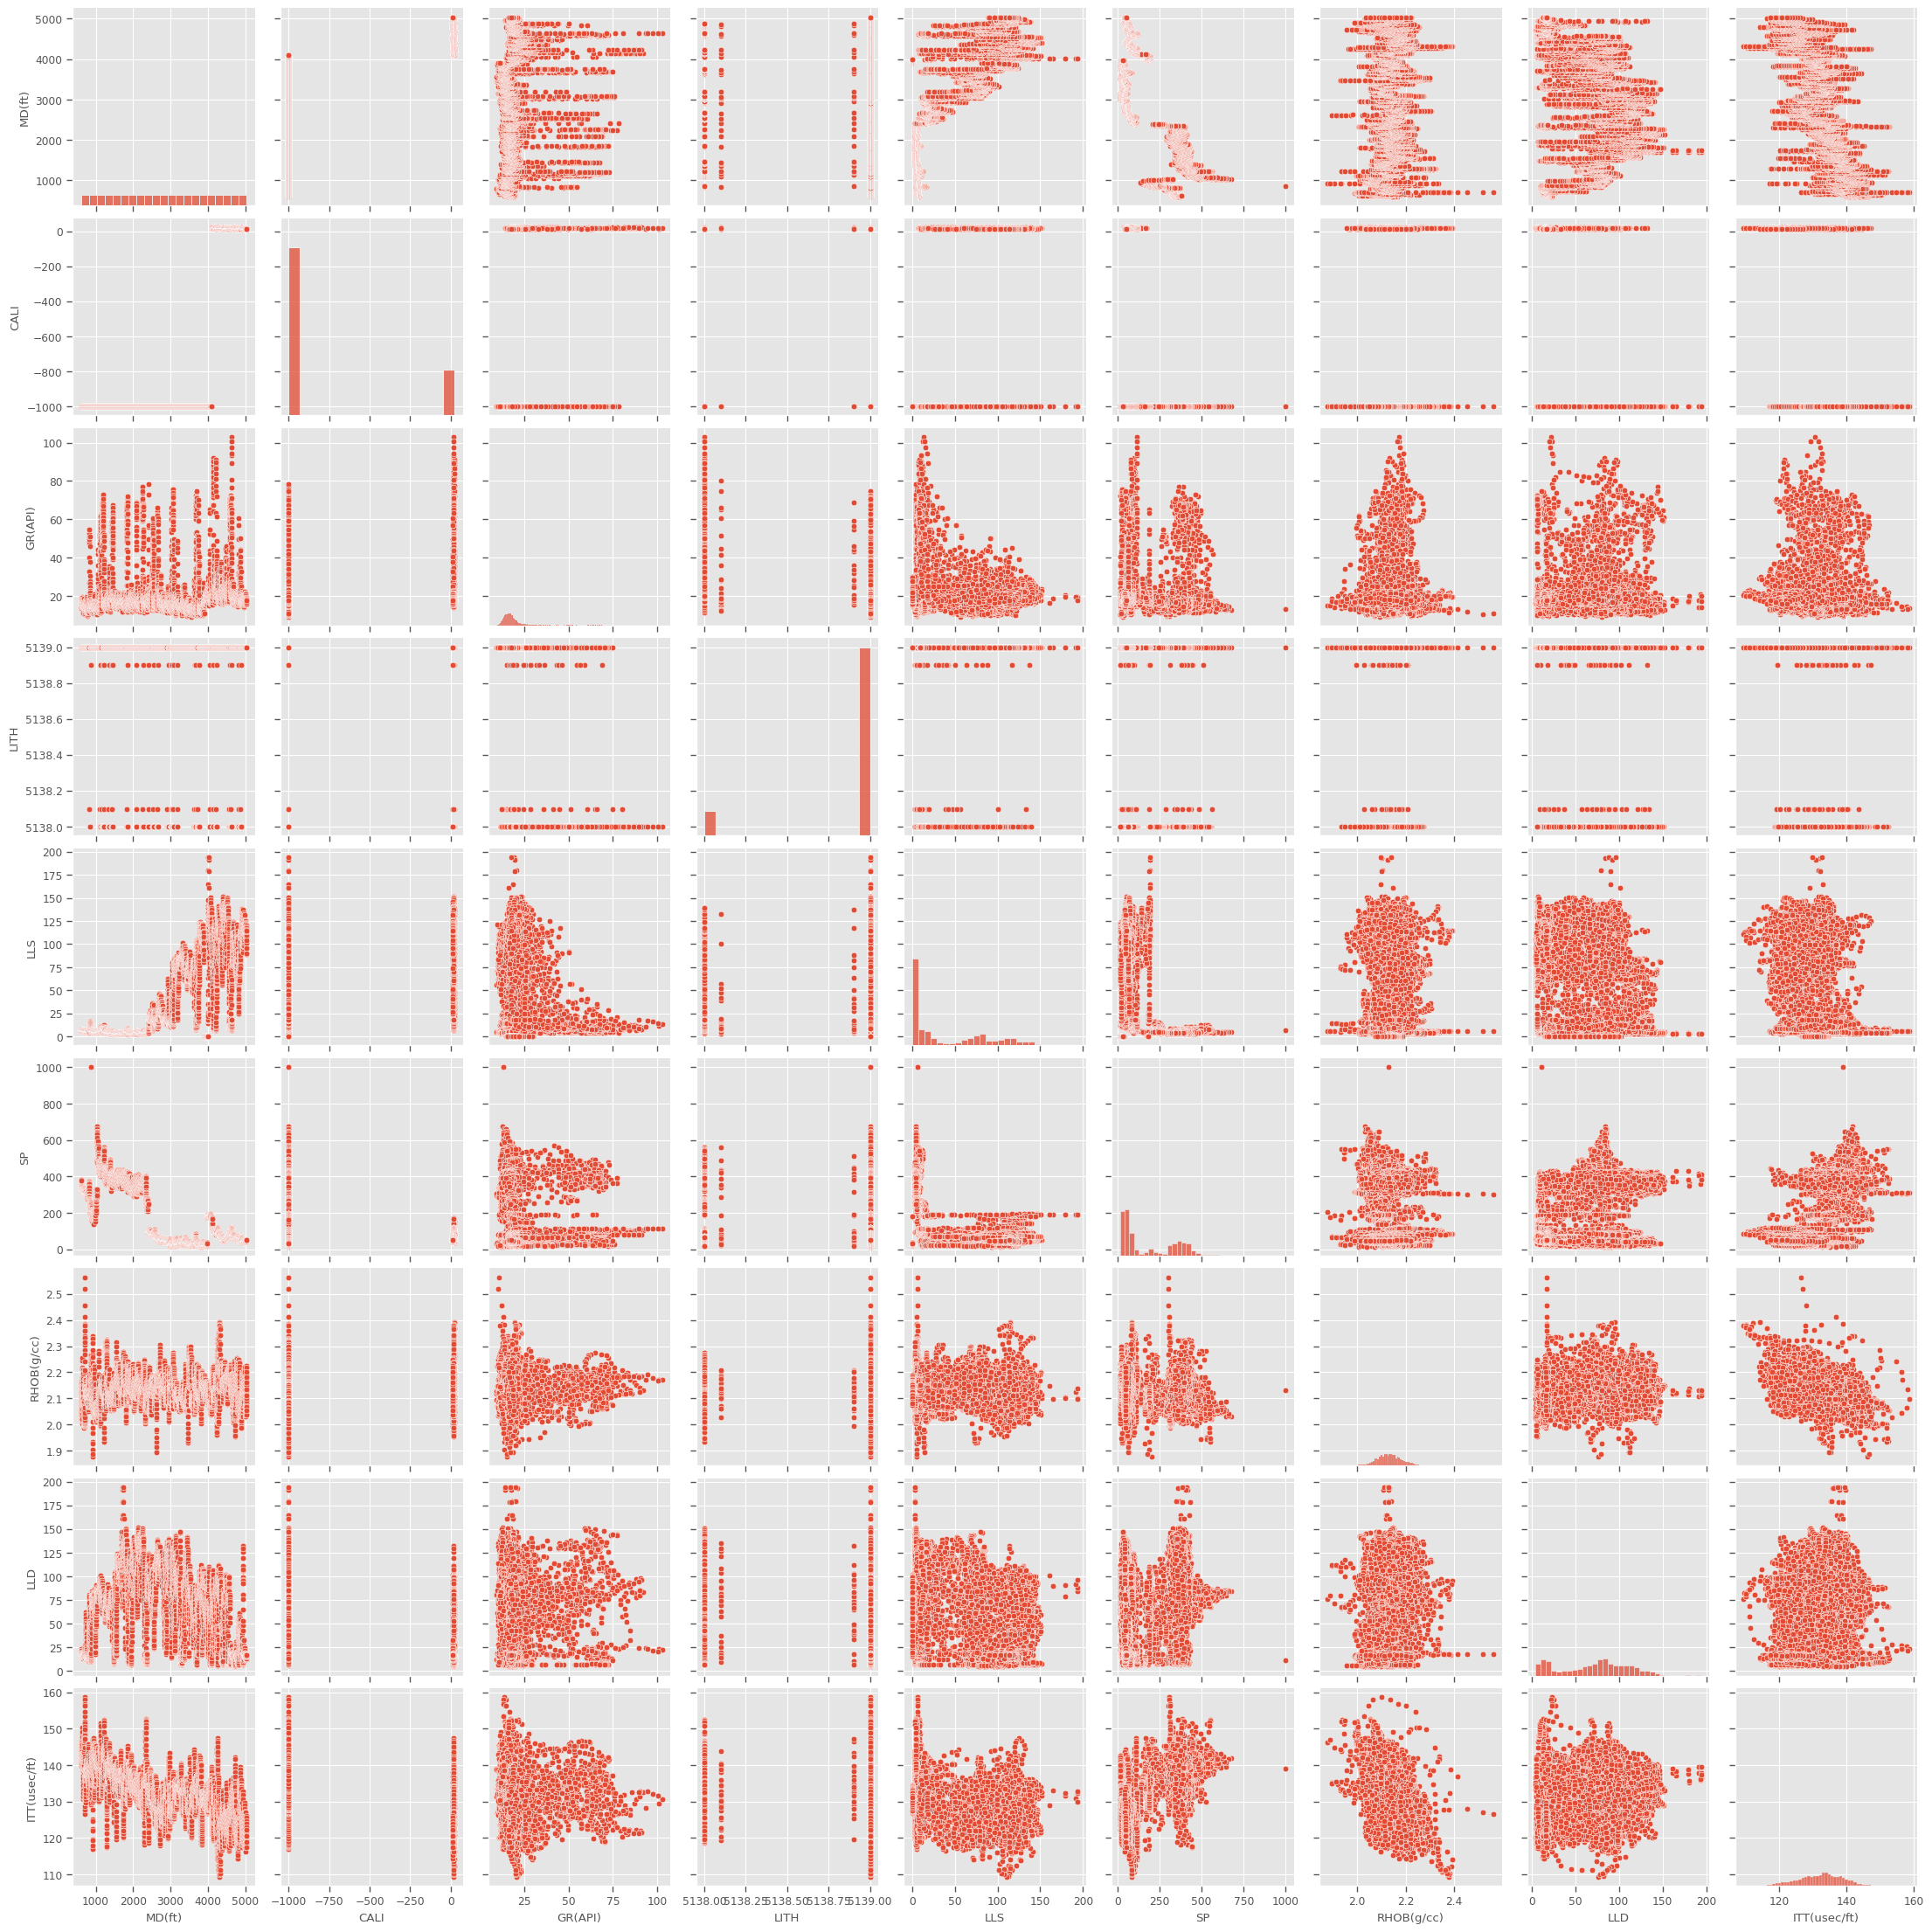

In [58]:
plt.figure(figsize=(5,5))
sns.pairplot(wellX)

## **Data Visualization**

In [59]:
wellX.columns

Index(['MD(ft)', 'CALI', 'GR(API)', 'LITH', 'LLS', 'SP', 'RHOB(g/cc)', 'LLD',
       'ITT(usec/ft)'],
      dtype='object', name=22)

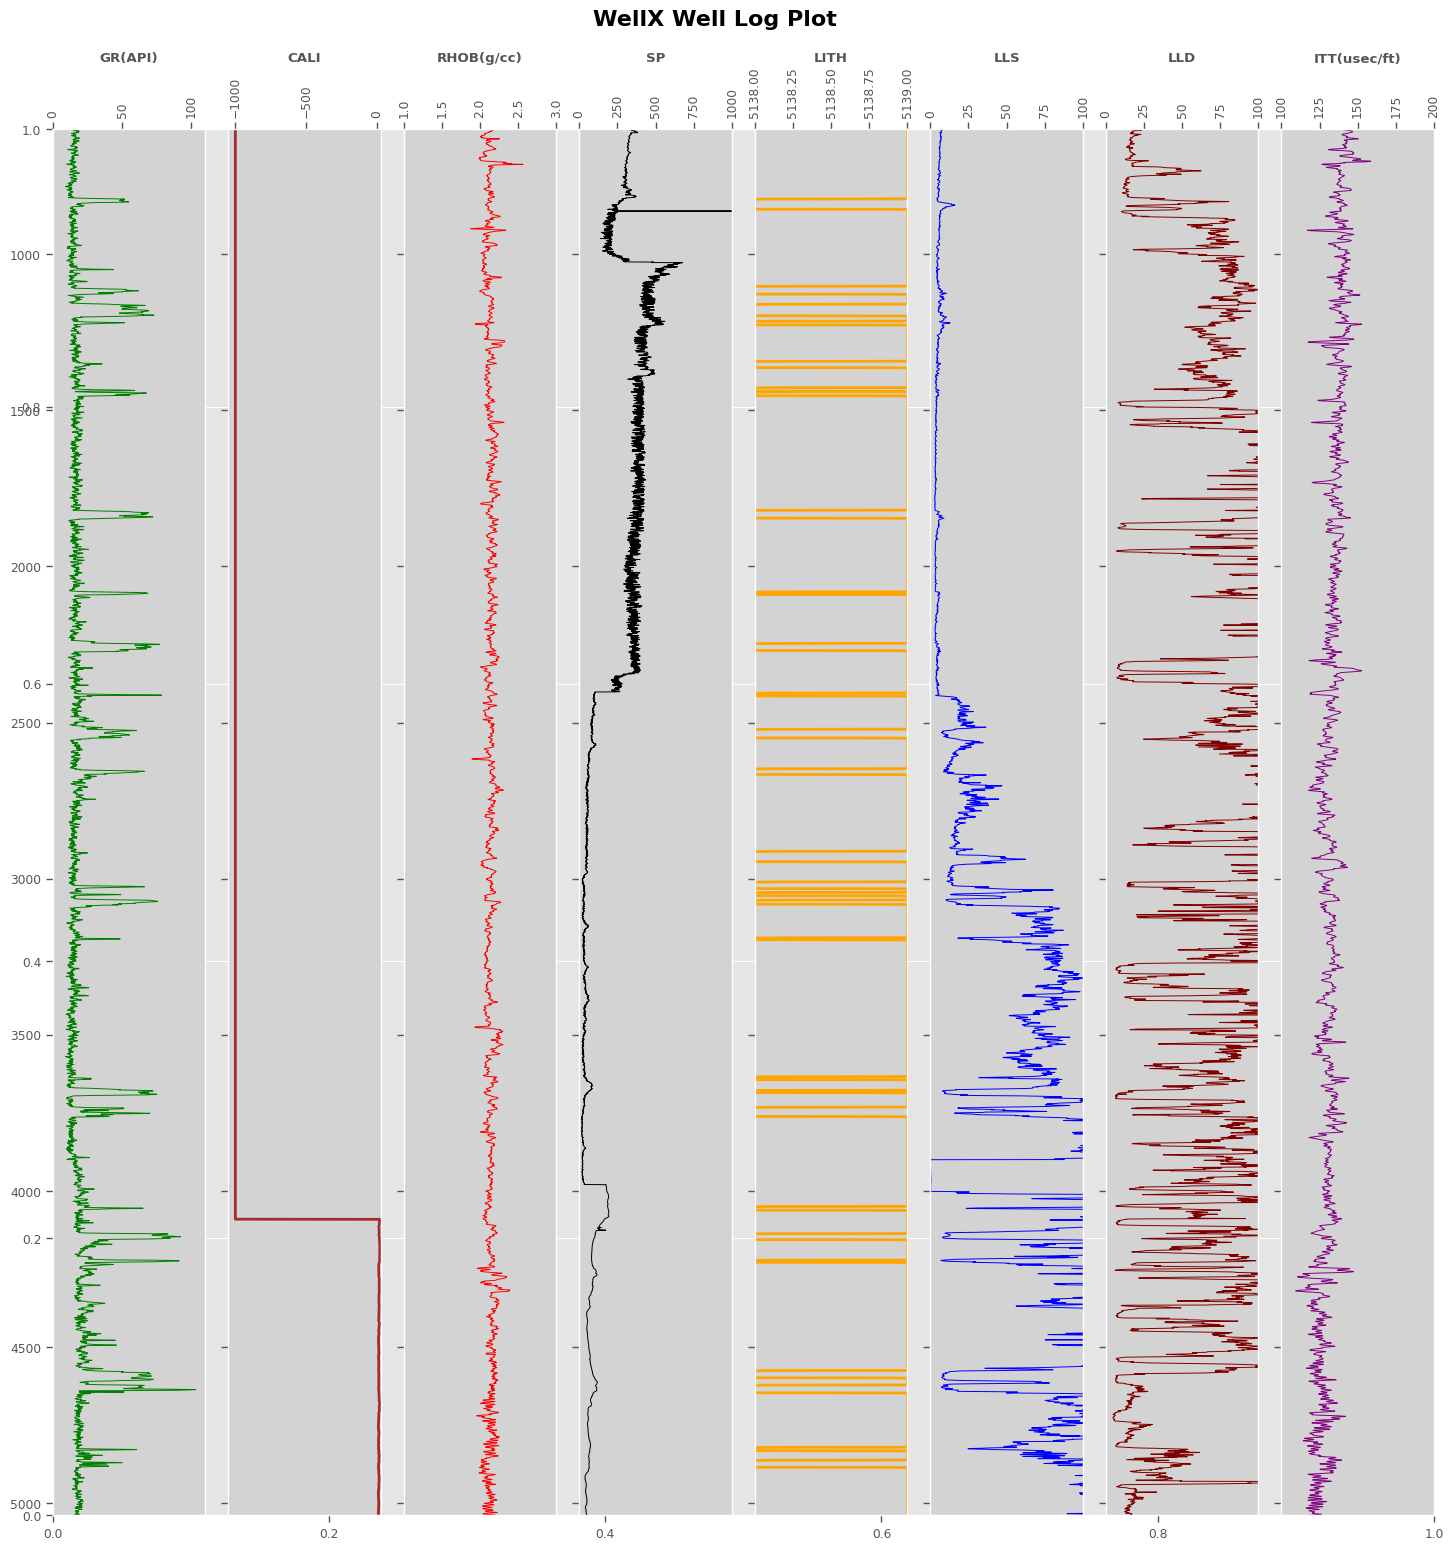

In [60]:
fig, axax = plt.subplots(figsize =(15,15))

ax1 = plt.subplot2grid((1,8),(0,0), rowspan=1, colspan = 1)
ax2 = plt.subplot2grid((1,8),(0,1), rowspan=1, colspan = 1)
ax3 = plt.subplot2grid((1,8),(0,2), rowspan=1, colspan = 1)
ax4 = plt.subplot2grid((1,8),(0,3), rowspan=1, colspan = 1)
ax5 = plt.subplot2grid((1,8),(0,4), rowspan=1, colspan = 1)
ax6 = plt.subplot2grid((1,8),(0,5), rowspan=1, colspan = 1)
ax7 = plt.subplot2grid((1,8),(0,6), rowspan=1, colspan = 1)
ax8 = plt.subplot2grid((1,8),(0,7), rowspan=1, colspan = 1)

ax1.plot('GR(API)','MD(ft)', data = wellX, color = "green", linewidth=0.7)
ax2.plot('CALI','MD(ft)', data = wellX, color = "brown", linewidth=2)
ax3.plot('RHOB(g/cc)','MD(ft)', data = wellX, color = "red", linewidth=0.7)
ax4.plot('SP','MD(ft)', data = wellX, color = "black", linewidth=0.7)
ax5.plot('LITH', 'MD(ft)', data=wellX, color='orange', linewidth=2)
ax6.plot('LLS','MD(ft)', data = wellX, color = "blue", linewidth=0.7)
ax7.plot('LLD','MD(ft)', data = wellX, color = "maroon", linewidth=0.7)
ax8.plot('ITT(usec/ft)','MD(ft)', data = wellX, color = "purple", linewidth=0.7)

ax1.set_xlabel('GR(API)', fontweight="bold")
ax1.tick_params(labelbottom=False,labeltop=True)
ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.set_xlim(0,110)
ax1.set_ylim(5039.500,600)
ax1.set_facecolor("lightgrey")
for ticks in ax1.xaxis.get_ticklabels():
  ticks.set_rotation(90)
ax1.grid()

ax2.set_xlabel("CALI", fontweight="bold")
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()
ax2.set_xlim(-1050,30)
ax2.set_ylim(5039.500,600)
ax2.set_facecolor("lightgrey")
for ticks in ax2.xaxis.get_ticklabels():
  ticks.set_rotation(90)
ax2.grid()

ax3.set_xlabel("RHOB(g/cc)", fontweight="bold")
ax3.set_xlim(1,3)
ax3.set_ylim(5039.500,600)
ax3.set_facecolor("lightgrey")
ax3.xaxis.set_label_position('top')
ax3.xaxis.tick_top()
for ticks in ax3.xaxis.get_ticklabels():
  ticks.set_rotation(90)
ax3.grid()

ax4.set_xlabel("SP", fontweight="bold")
ax4.set_xlim(0,1000)
ax4.set_ylim(5039.500,600)
ax4.xaxis.set_label_position('top')
ax4.xaxis.tick_top()
ax4.set_facecolor("lightgrey")
for ticks in ax4.xaxis.get_ticklabels():
  ticks.set_rotation(90)
ax4.grid()

ax5.set_xlabel("LITH", fontweight="bold")
ax5.set_xlim(5138,5139)
ax5.set_ylim(5039.500,600)
ax5.xaxis.set_label_position('top')
ax5.xaxis.tick_top()
ax5.set_facecolor("lightgrey")
for ticks in ax5.xaxis.get_ticklabels():
  ticks.set_rotation(90)
ax5.grid()

ax6.set_xlabel("LLS", fontweight="bold")
ax6.set_xlim(0,100)
ax6.set_ylim(5039.500,600)
ax6.set_facecolor("lightgrey")
ax6.xaxis.set_label_position('top')
ax6.xaxis.tick_top()
for ticks in ax6.xaxis.get_ticklabels():
  ticks.set_rotation(90)
ax6.grid()

ax7.set_xlabel("LLD", fontweight="bold")
ax7.set_xlim(0,100)
ax7.set_ylim(5039.500,600)
ax7.xaxis.set_label_position('top')
ax7.xaxis.tick_top()
ax7.set_facecolor("lightgrey")
for ticks in ax7.xaxis.get_ticklabels():
  ticks.set_rotation(90)
ax7.grid()

ax8.set_xlabel("ITT(usec/ft)", fontweight="bold")
ax8.set_xlim(100,200)
ax8.set_ylim(5039.500,600)
ax8.xaxis.set_label_position('top')
ax8.xaxis.tick_top()
ax8.set_facecolor("lightgrey")
for ticks in ax8.xaxis.get_ticklabels():
  ticks.set_rotation(90)
ax8.grid()

for ax in [ax2,ax3,ax3,ax4, ax5,ax6,ax7,ax8]:
  plt.setp(ax.get_yticklabels(), visible=False)

fig.suptitle("WellX Well Log Plot", size=16, fontweight="bold", y=1.03)
fig.align_labels()
plt.tight_layout()
plt.xticks(rotation=90)
fig.subplots_adjust(wspace=0.15)
fig.subplots_adjust(top=0.95)

## **Imposing Plots (variables vs measured depth)**

Gamma Ray and SP log Vs Measured Depth

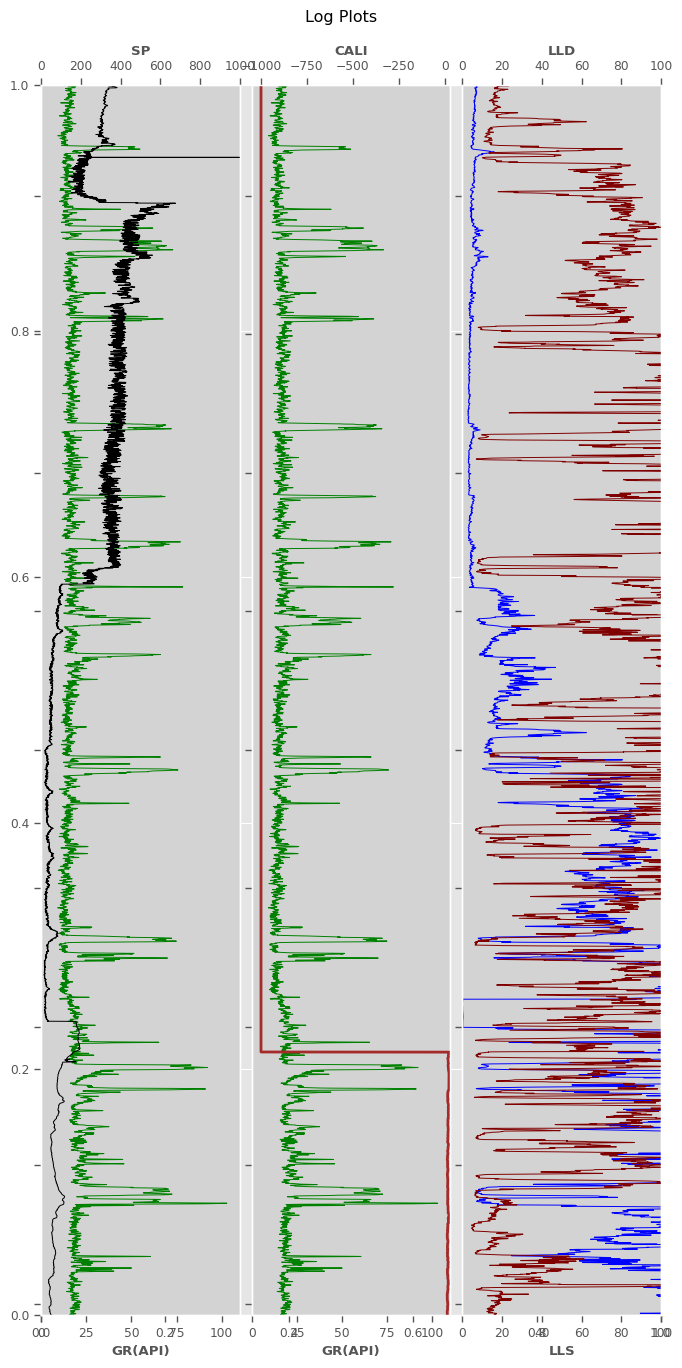

In [61]:
fig, ax = plt.subplots(figsize =(8,15))

ax1 = plt.subplot2grid((1,3),(0,0), rowspan=1, colspan = 1)
ax1a = plt.subplot2grid((1,3),(0,1), rowspan=1, colspan = 1)
ax2 = ax1a.twiny()
ax4 = ax1.twiny()
ax6 = plt.subplot2grid((1,3),(0,2), rowspan=1, colspan = 1)
ax7 = ax6.twiny()
#ax1g = ax6.twiny()


ax1.plot('GR(API)','MD(ft)', data = wellX, color = "green", linewidth=0.7)
ax1a.plot('GR(API)','MD(ft)', data = wellX, color = "green", linewidth=0.7)
ax4.plot('SP','MD(ft)', data = wellX, color = "black", linewidth=0.7)
ax2.plot('CALI','MD(ft)', data = wellX, color = "brown", linewidth=2)
ax6.plot('LLS','MD(ft)', data = wellX, color = "blue", linewidth=0.7)
ax7.plot('LLD','MD(ft)', data = wellX, color = "maroon", linewidth=0.7)

ax1.set_xlabel('GR(API)', fontweight="bold")
ax1.set_xlim(0,110)
ax1.set_ylim(5039.500,600)
ax1.set_facecolor("lightgrey")
ax1.grid()
ax1a.grid()
ax4.set_xlabel("SP", fontweight="bold")
ax4.set_xlim(0,1000)
ax4.grid()

ax1.set_xlabel('GR(API)', fontweight="bold")
ax1.set_xlim(0,110)
ax1.set_ylim(5039.500,600)
ax1a.set_xlabel('GR(API)', fontweight="bold")
ax1a.set_xlim(0,110)
ax1a.set_ylim(5039.500,600)
ax1a.set_facecolor("lightgrey")
ax2.set_xlabel("CALI", fontweight="bold")
ax2.set_xlim(-1050,30)
ax2.grid()

ax6.set_xlabel("LLS", fontweight="bold")
ax6.set_xlim(0,100)
ax6.set_ylim(5039.500,600)
ax6.set_facecolor("lightgrey")
#for ticks in ax6.xaxis.get_ticklabels():
  #ticks.set_rotation(90)
ax6.grid()

ax7.set_xlabel("LLD", fontweight="bold")
ax7.set_xlim(0,100)
ax7.set_ylim(5039.500,600)
ax7.set_facecolor("lightgrey")
#for ticks in ax7.xaxis.get_ticklabels():
  #ticks.set_rotation(90)
ax7.grid()

for ax in [ax1,ax1a,ax2,ax4,ax6,ax7]:
  plt.setp(ax.get_yticklabels(), visible=False)


plt.suptitle('Log Plots')
fig.subplots_adjust(top=0.93)
fig.subplots_adjust(wspace=0.06)

plt.savefig("Log Plots.jpeg")



# **Model Building**

## **Data Transformation**

The individual well logs have their own scales thus we need to scale the values to a common scale

In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [63]:
wellX.columns

Index(['MD(ft)', 'CALI', 'GR(API)', 'LITH', 'LLS', 'SP', 'RHOB(g/cc)', 'LLD',
       'ITT(usec/ft)'],
      dtype='object', name=22)

In [64]:
wellX[['MD.T', 'CALI.T', 'GR.T', 'LITH.T', 'LLS.T', 'SP.T', 'RHOB.T', 'LLD.T','ITT.T']] = scaler.fit_transform(wellX[['MD(ft)', 'CALI', 'GR(API)', 'LITH', 'LLS', 'SP', 'RHOB(g/cc)', 'LLD',
       'ITT(usec/ft)']])

In [65]:
wellX.head()

22,MD(ft),CALI,GR(API),LITH,LLS,SP,RHOB(g/cc),LLD,ITT(usec/ft),MD.T,CALI.T,GR.T,LITH.T,LLS.T,SP.T,RHOB.T,LLD.T,ITT.T
0,600.0,-999.25,16.505,5139.0,7.874,337.457,2.159,19.763,139.912,-1.731856,-0.521382,-0.341096,0.365199,-0.761198,0.969067,0.427491,-1.331336,1.148172
1,600.5,-999.25,17.685,5139.0,7.892,337.457,2.157,19.056,140.616,-1.731466,-0.521382,-0.243401,0.365199,-0.760795,0.969067,0.391676,-1.349728,1.255667
2,601.0,-999.25,18.962,5139.0,7.785,337.457,2.159,18.729,140.732,-1.731076,-0.521382,-0.137675,0.365199,-0.763188,0.969067,0.427491,-1.358234,1.273379
3,601.5,-999.25,19.122,5139.0,7.713,339.777,2.160,19.208,140.920,-1.730685,-0.521382,-0.124428,0.365199,-0.764799,0.983642,0.445398,-1.345774,1.302085
4,602.0,-999.25,18.014,5139.0,7.691,343.256,2.162,20.818,142.288,-1.730295,-0.521382,-0.216162,0.365199,-0.765291,1.005498,0.481213,-1.303892,1.510968


In [66]:
wellZ = wellX[['MD.T', 'CALI.T', 'GR.T', 'LITH.T', 'LLS.T', 'SP.T', 'RHOB.T', 'LLD.T','ITT.T']]
wellZ.head()

22,MD.T,CALI.T,GR.T,LITH.T,LLS.T,SP.T,RHOB.T,LLD.T,ITT.T
0,-1.731856,-0.521382,-0.341096,0.365199,-0.761198,0.969067,0.427491,-1.331336,1.148172
1,-1.731466,-0.521382,-0.243401,0.365199,-0.760795,0.969067,0.391676,-1.349728,1.255667
2,-1.731076,-0.521382,-0.137675,0.365199,-0.763188,0.969067,0.427491,-1.358234,1.273379
3,-1.730685,-0.521382,-0.124428,0.365199,-0.764799,0.983642,0.445398,-1.345774,1.302085
4,-1.730295,-0.521382,-0.216162,0.365199,-0.765291,1.005498,0.481213,-1.303892,1.510968


Implementing K-Means Clustering

In [67]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

In [70]:
def kmeans_clusters(data, max_k):
  cluster_k = []
  wss = [] #within sum of squares or intertias
  for i in range(1,max_k):
    k_clustering = KMeans(n_clusters=i,init='k-means++', random_state=2, max_iter=200,algorithm='elkan')
    k_clustering.fit(data)


    cluster_k.append(i)
    wss.append(k_clustering.inertia_)

  #plotting an elbow plot for generated k values.
  fig = plt.subplots(figsize = (20,8))
  plt.plot(cluster_k, wss, "o-", color = 'b')
  plt.xlabel('Number of Clusters', fontweight = "bold", size =12)
  plt.ylabel('WSS/Inertia', fontweight = "bold", size = 12)
  plt.title('Elbow Plot for K Number of Clusters', size = 14, fontweight='bold')
  plt.grid(True)
  plt.show()

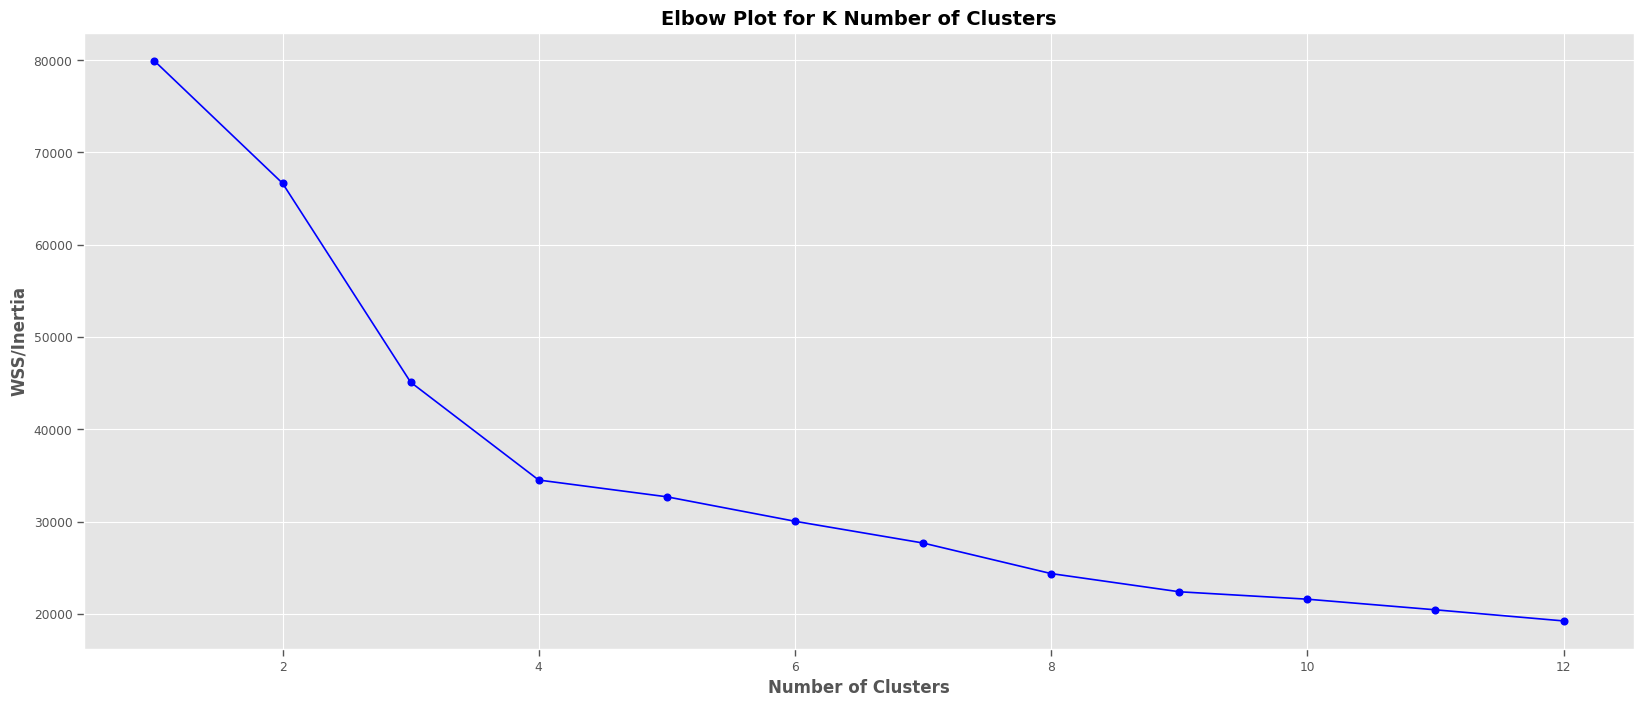

In [71]:
kmeans_clusters(wellZ,13)

For n_clusters = 2 The average silhouette_score is : 0.29091291284393966
For n_clusters = 3 The average silhouette_score is : 0.3025008379973811
For n_clusters = 4 The average silhouette_score is : 0.335579608887322
For n_clusters = 5 The average silhouette_score is : 0.3041247932899974
For n_clusters = 6 The average silhouette_score is : 0.2883398311059591


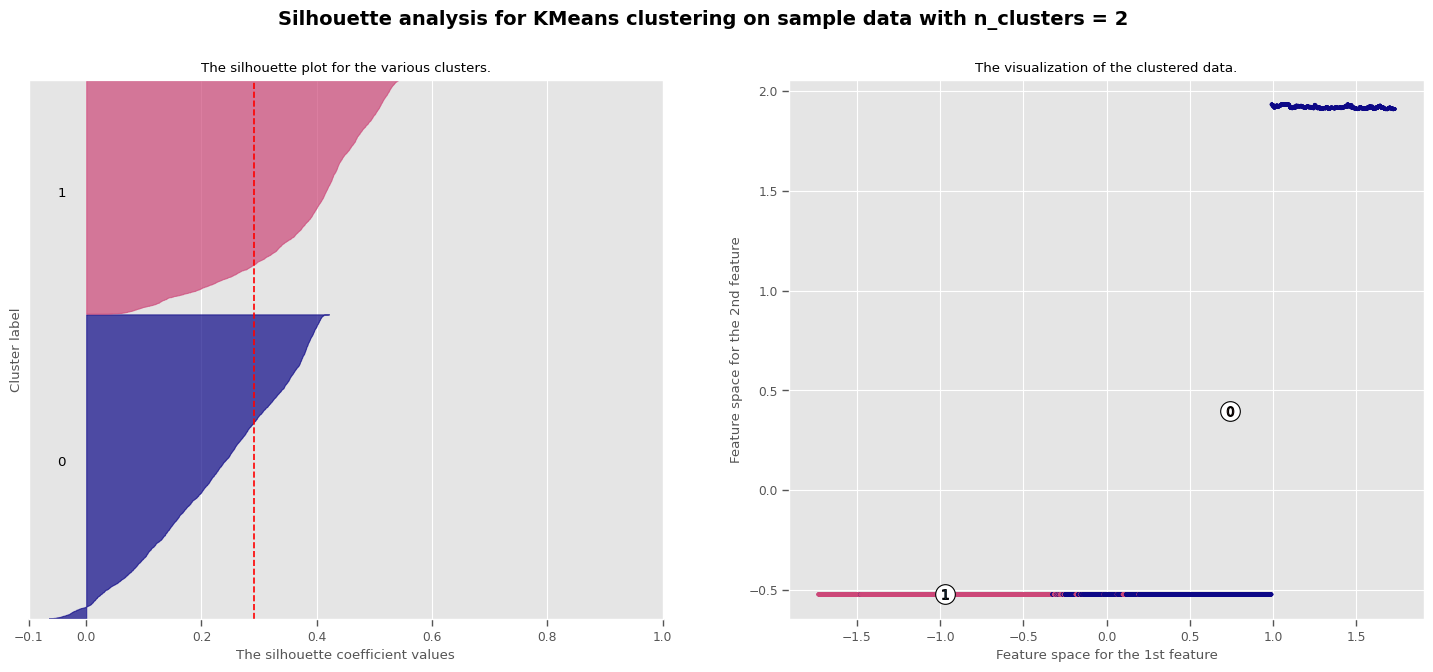

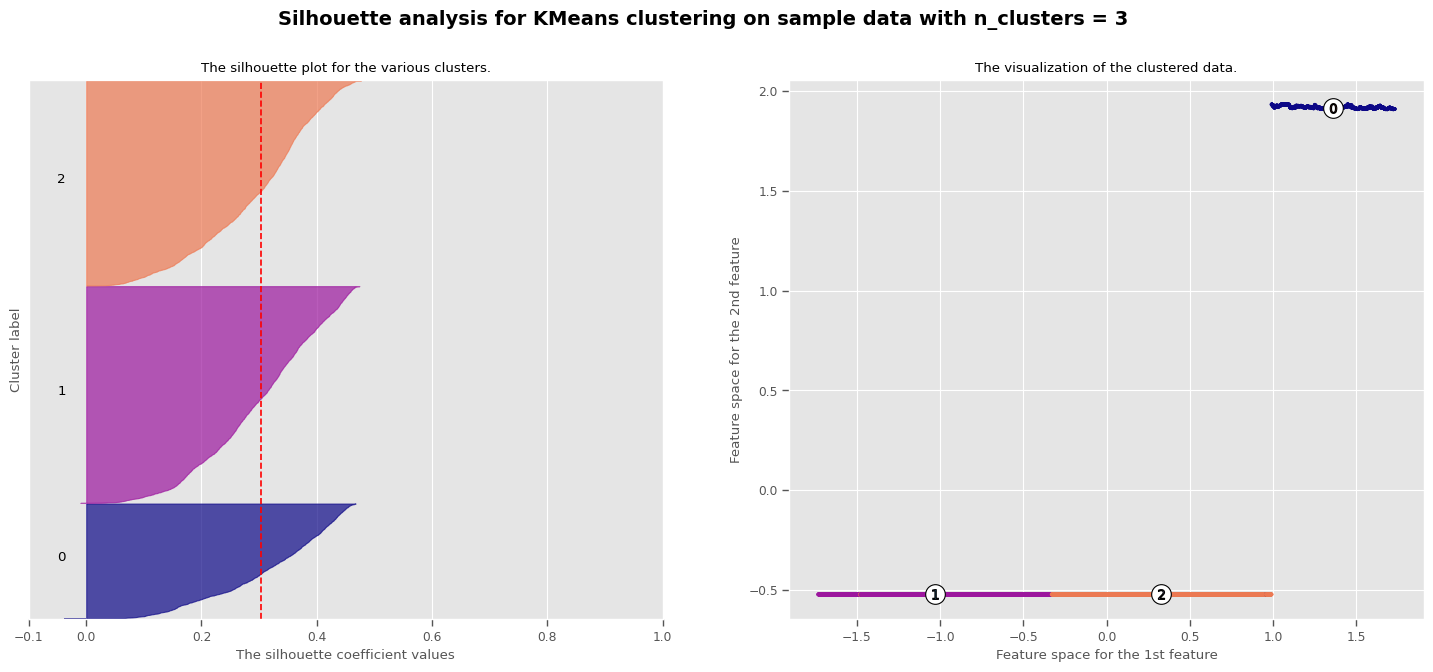

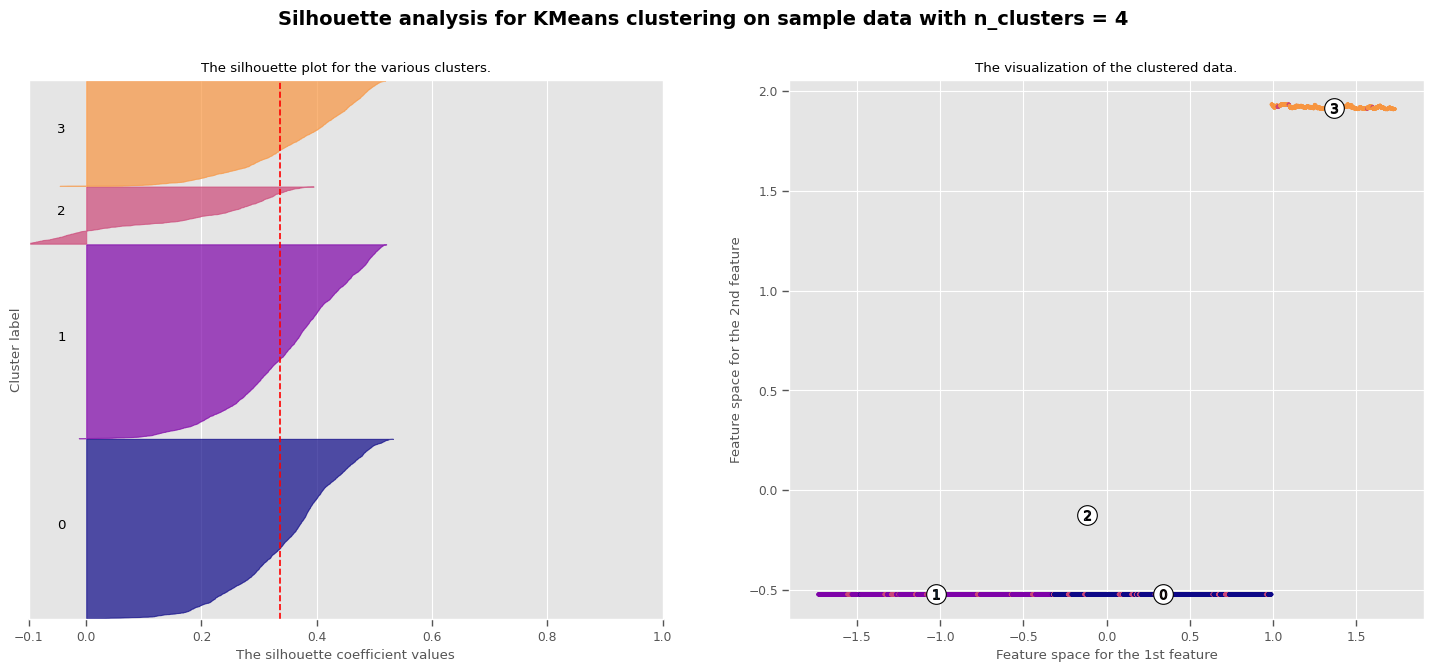

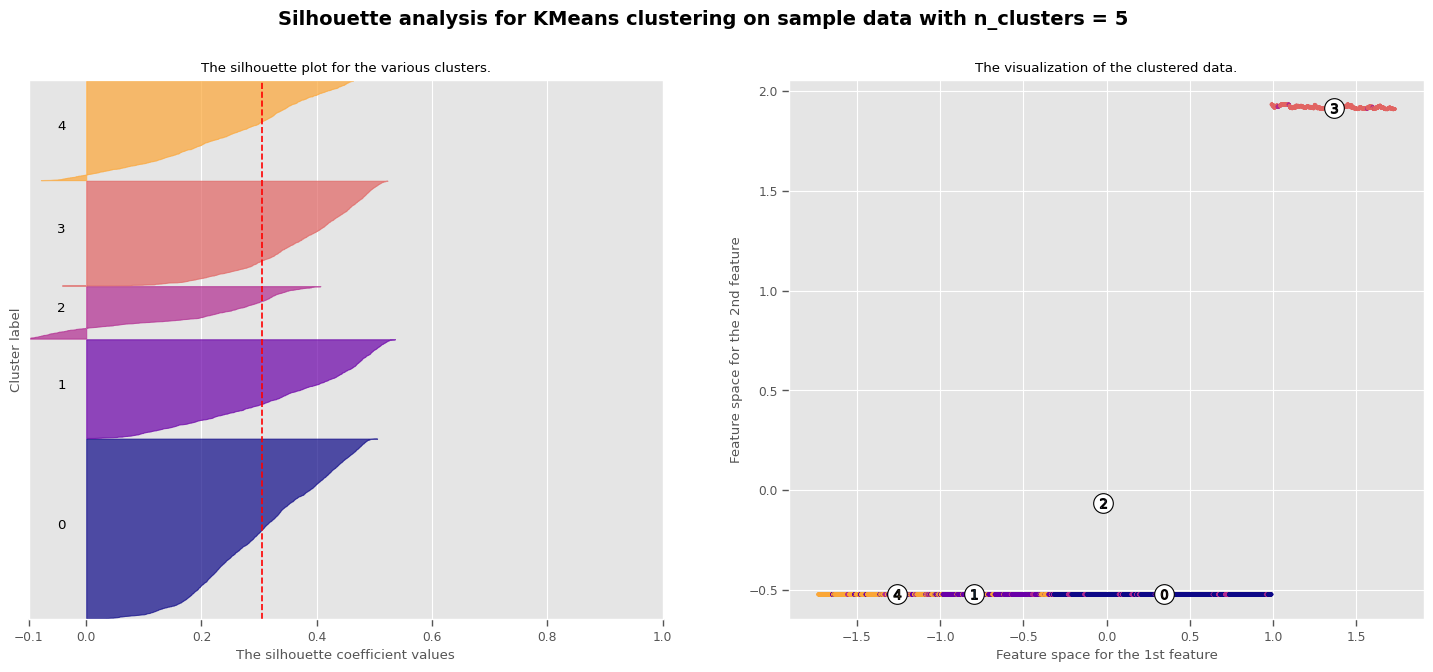

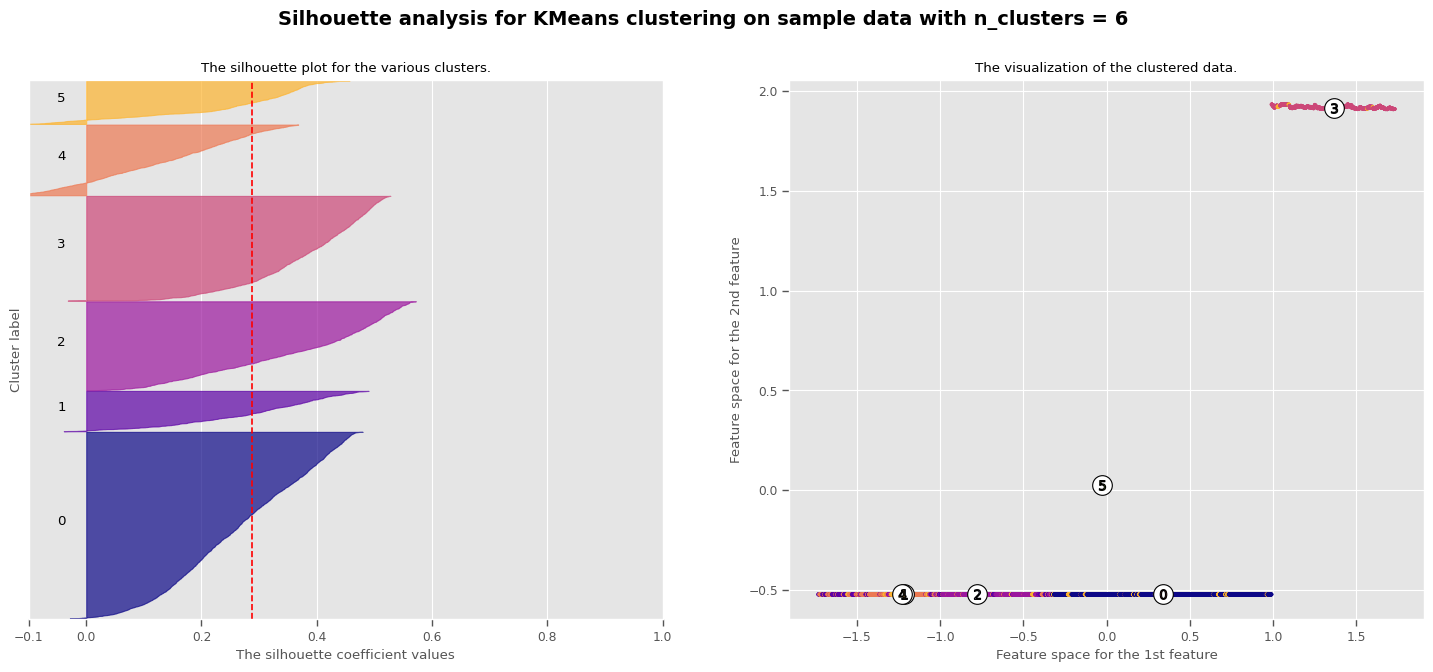

In [72]:
#Sklearn's Silhoutte's sample code for determining suitable number of clusters.
range_n_clusters = [2, 3, 4, 5, 6,]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(wellZ) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(wellZ)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(wellZ, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(wellZ, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.plasma(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.plasma(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        wellZ.iloc[:, 0], wellZ.iloc[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

From the Silhouette analysis, we can see that although the 4 clusters has the highest coefficients, the 3 clusters (from the visualization) actually splitted the datasets better than the 4 clusters with little data points clustered wrongly (data points with extremely low silohouette score).

The 3 cluster points will be selected.


# **Applying KMeans Clusterings from the Clusters with the Best Silhouette Score (clusters = 3)**

In [73]:
kmeans = KMeans(n_clusters = 3)
kmeans.fit(wellZ)
wellZ['Kmeans_3'] = kmeans.labels_
wellZ.head(10)

22,MD.T,CALI.T,GR.T,LITH.T,LLS.T,SP.T,RHOB.T,LLD.T,ITT.T,Kmeans_3
0,-1.731856,-0.521382,-0.341096,0.365199,-0.761198,0.969067,0.427491,-1.331336,1.148172,2
1,-1.731466,-0.521382,-0.243401,0.365199,-0.760795,0.969067,0.391676,-1.349728,1.255667,2
2,-1.731076,-0.521382,-0.137675,0.365199,-0.763188,0.969067,0.427491,-1.358234,1.273379,2
3,-1.730685,-0.521382,-0.124428,0.365199,-0.764799,0.983642,0.445398,-1.345774,1.302085,2
4,-1.730295,-0.521382,-0.216162,0.365199,-0.765291,1.005498,0.481213,-1.303892,1.510968,2
5,-1.729905,-0.521382,-0.344408,0.365199,-0.763278,1.020066,0.517028,-1.256027,1.696641,2
6,-1.729515,-0.521382,-0.463049,0.365199,-0.771530,1.005498,0.427491,-1.237895,1.762604,2
7,-1.729125,-0.521382,-0.471908,0.365199,-0.774885,0.990929,0.391676,-1.300120,1.871931,2
8,-1.728735,-0.521382,-0.407082,0.365199,-0.773924,1.078359,0.427491,-1.340181,1.971486,2
9,-1.728345,-0.521382,-0.307234,0.365199,-0.775131,1.078359,0.284231,-1.362579,1.989199,2


<Axes: xlabel='LITH.T', ylabel='GR.T'>

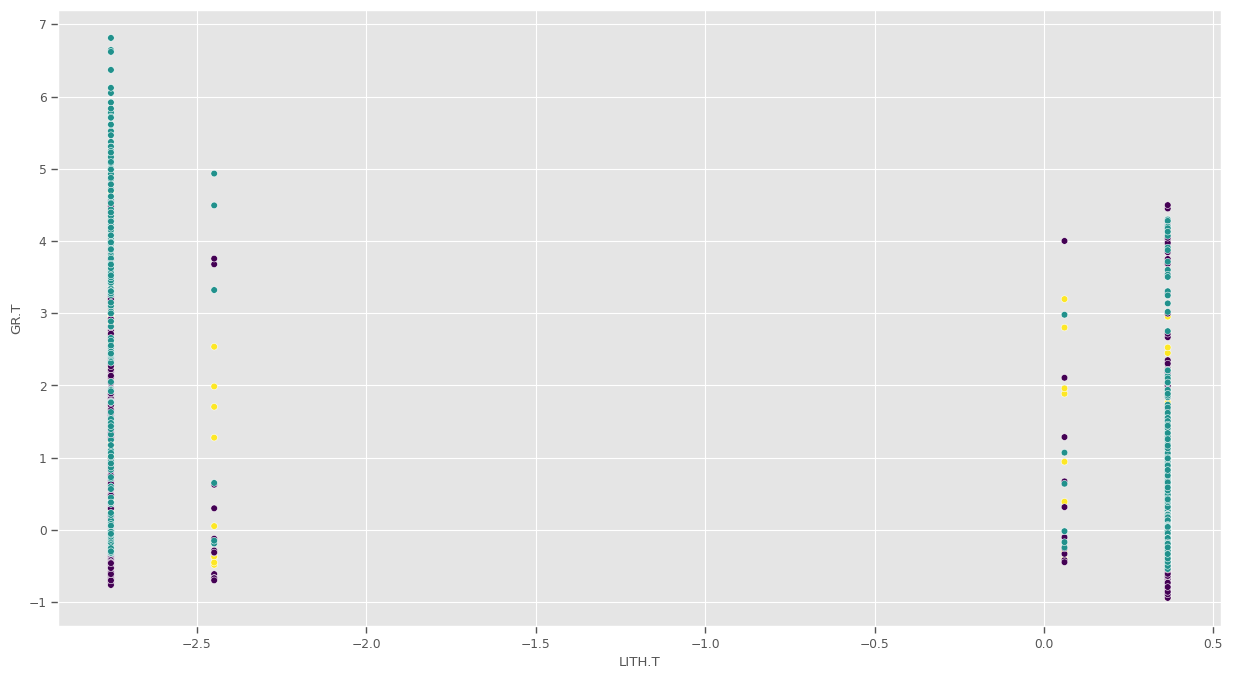

In [74]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = wellZ['LITH.T'], y = wellZ['GR.T'], c = wellZ['Kmeans_3'])

<Axes: xlabel='LITH.T', ylabel='RHOB.T'>

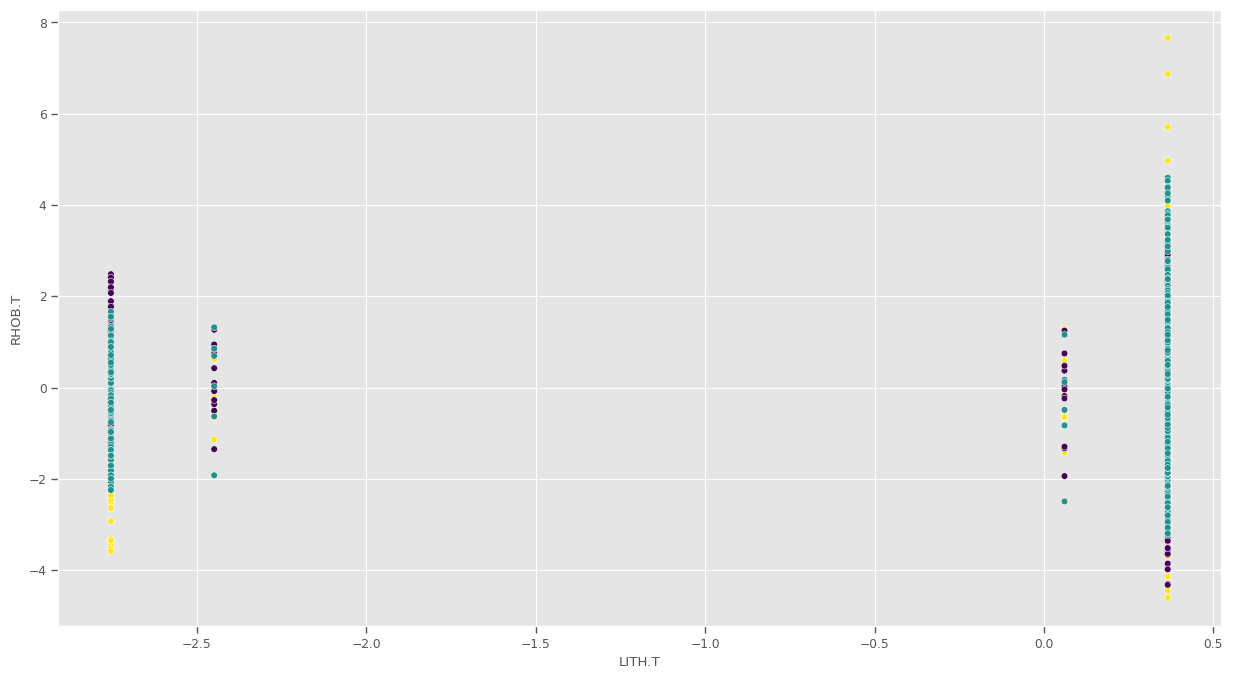

In [75]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = wellZ['LITH.T'], y = wellZ['RHOB.T'], c = wellZ['Kmeans_3'])

<Axes: xlabel='RHOB.T', ylabel='SP.T'>

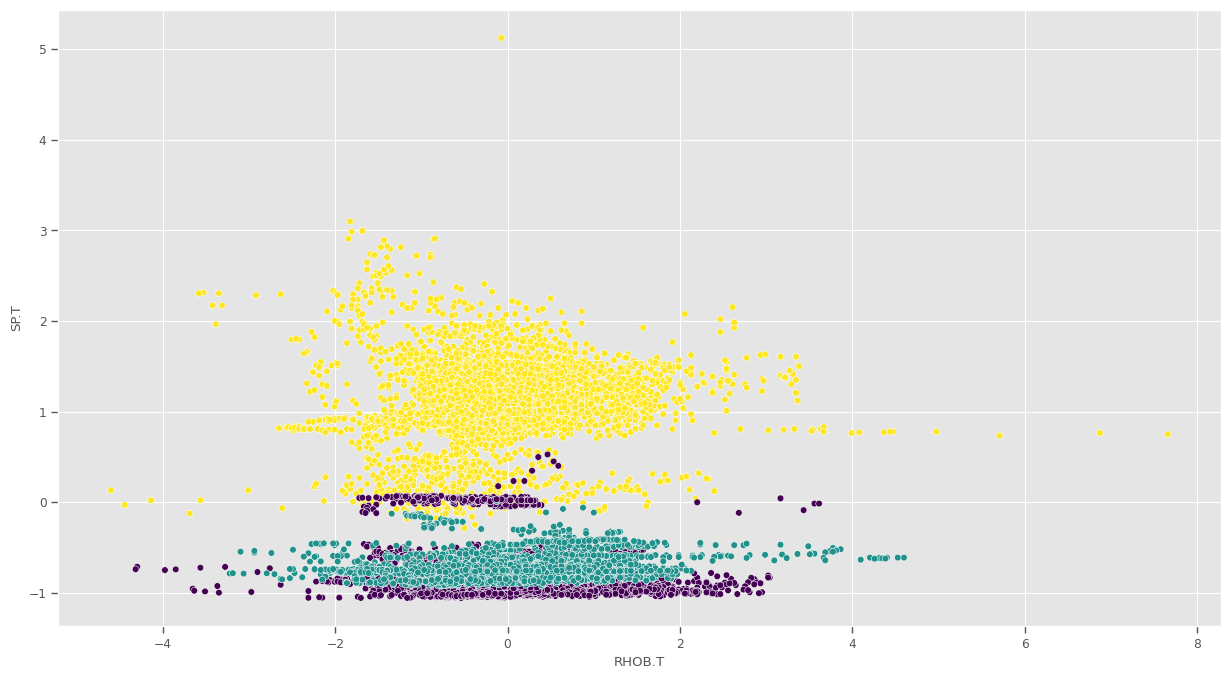

In [76]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = wellZ['RHOB.T'], y = wellZ['SP.T'], c = wellZ['Kmeans_3'])

<Axes: xlabel='GR.T', ylabel='SP.T'>

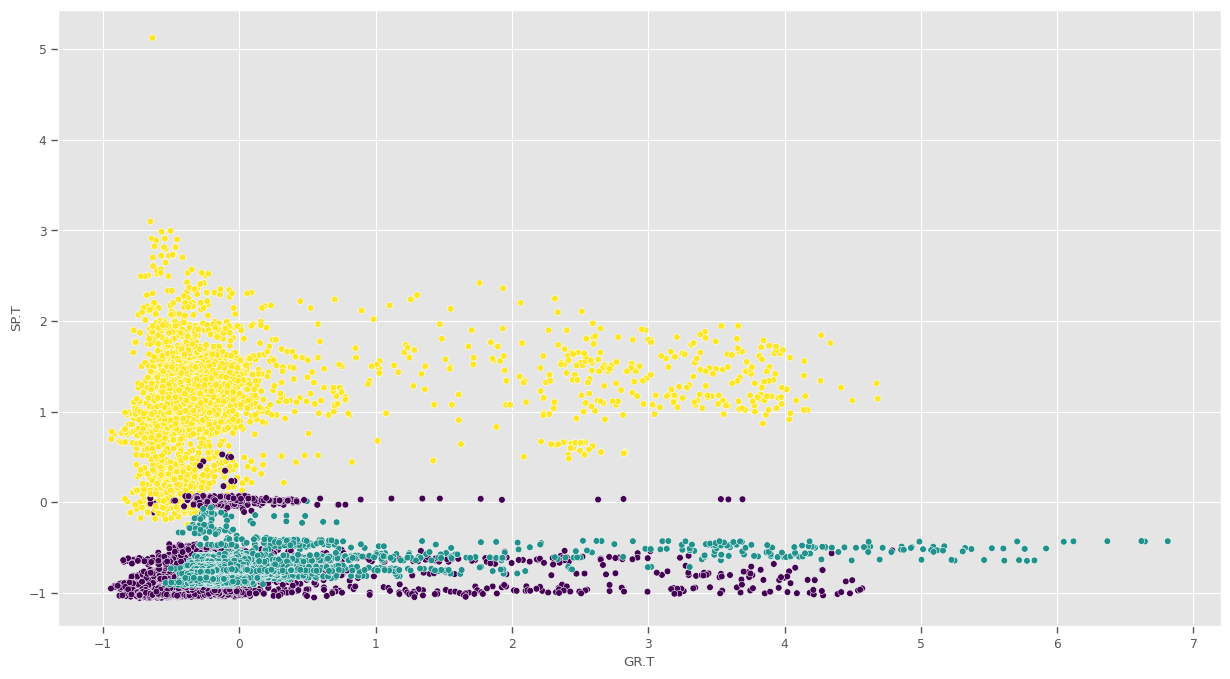

In [77]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = wellZ['GR.T'], y = wellZ['SP.T'], c = wellZ['Kmeans_3'])

<Axes: xlabel='LLD.T', ylabel='SP.T'>

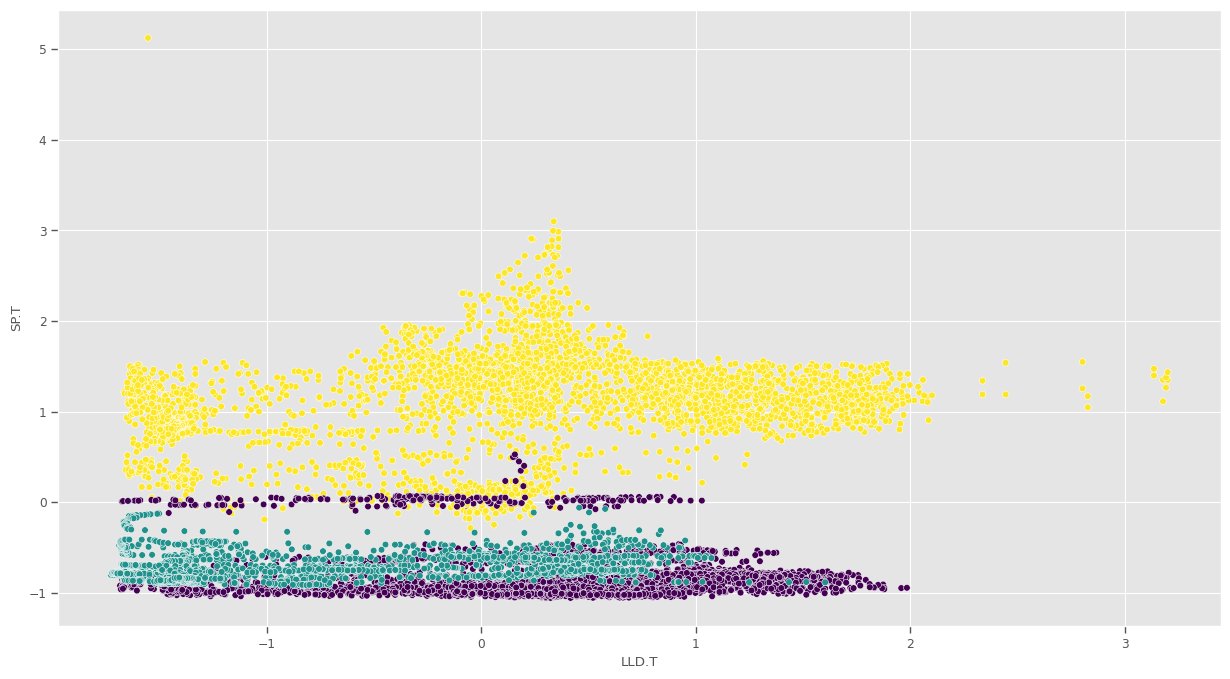

In [78]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = wellZ['LLD.T'], y = wellZ['SP.T'], c = wellZ['Kmeans_3'])

<Axes: xlabel='LLS.T', ylabel='SP.T'>

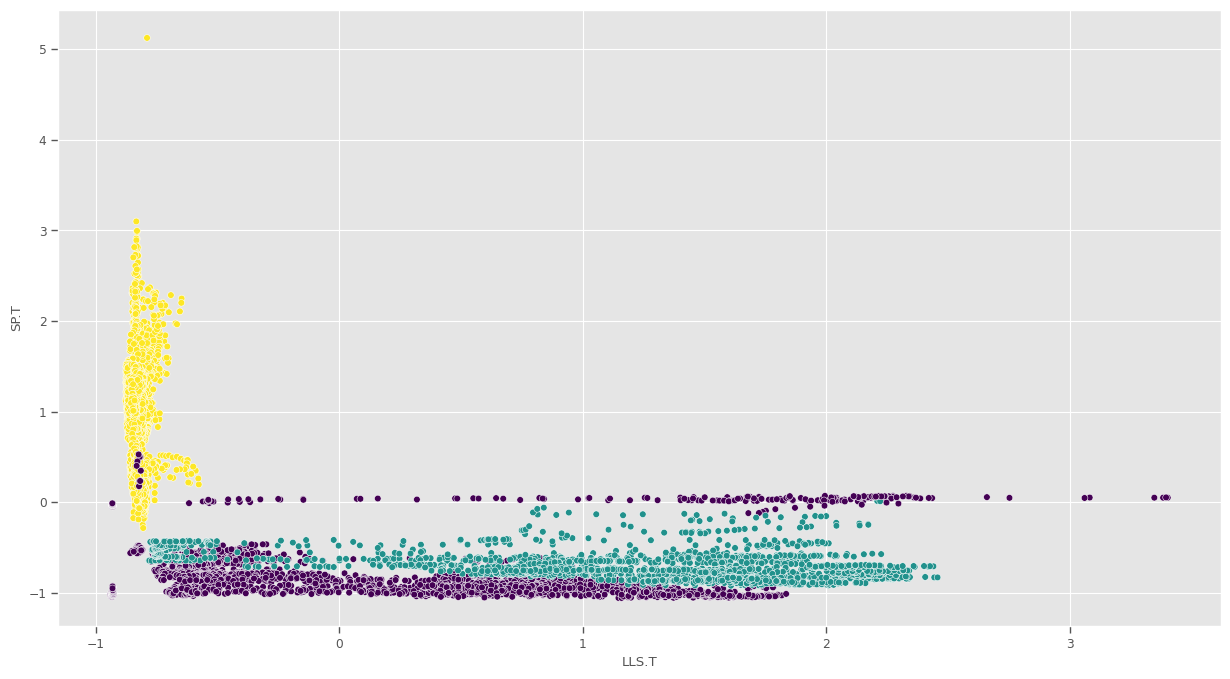

In [79]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = wellZ['LLS.T'], y = wellZ['SP.T'], c = wellZ['Kmeans_3'])

<Axes: xlabel='ITT.T', ylabel='SP.T'>

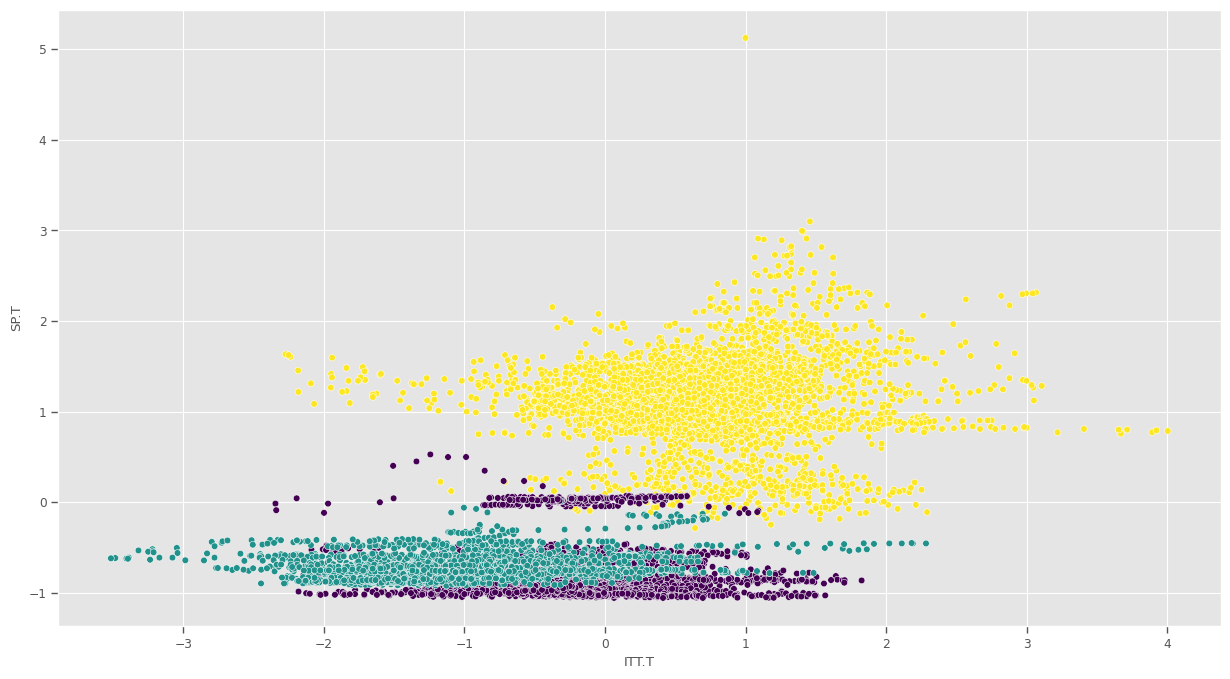

In [80]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = wellZ['ITT.T'], y = wellZ['SP.T'], c = wellZ['Kmeans_3'])

<Axes: xlabel='ITT.T', ylabel='RHOB.T'>

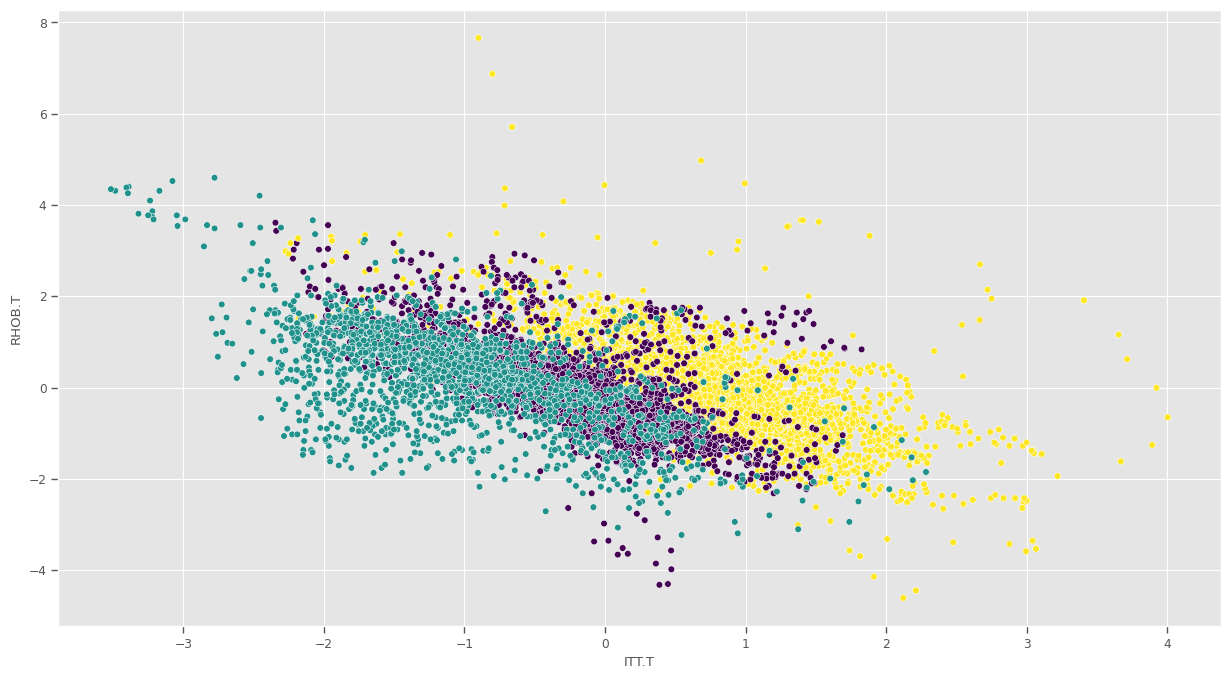

In [81]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = wellZ['ITT.T'], y = wellZ['RHOB.T'], c = wellZ['Kmeans_3'])

<Axes: xlabel='ITT.T', ylabel='GR.T'>

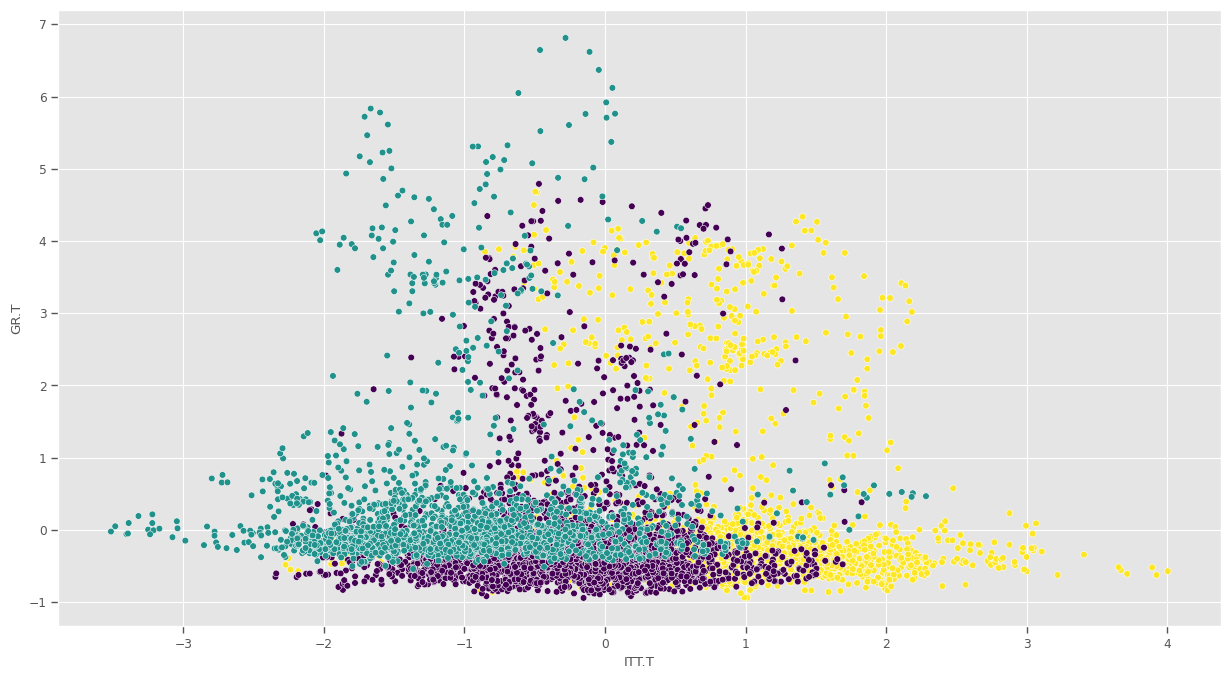

In [82]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = wellZ['ITT.T'], y = wellZ['GR.T'], c = wellZ['Kmeans_3'])


## **Agglomerative Clustering**

In [83]:
wellAC = wellX[['MD.T', 'CALI.T', 'GR.T', 'LITH.T', 'LLS.T', 'SP.T', 'RHOB.T', 'LLD.T','ITT.T']]

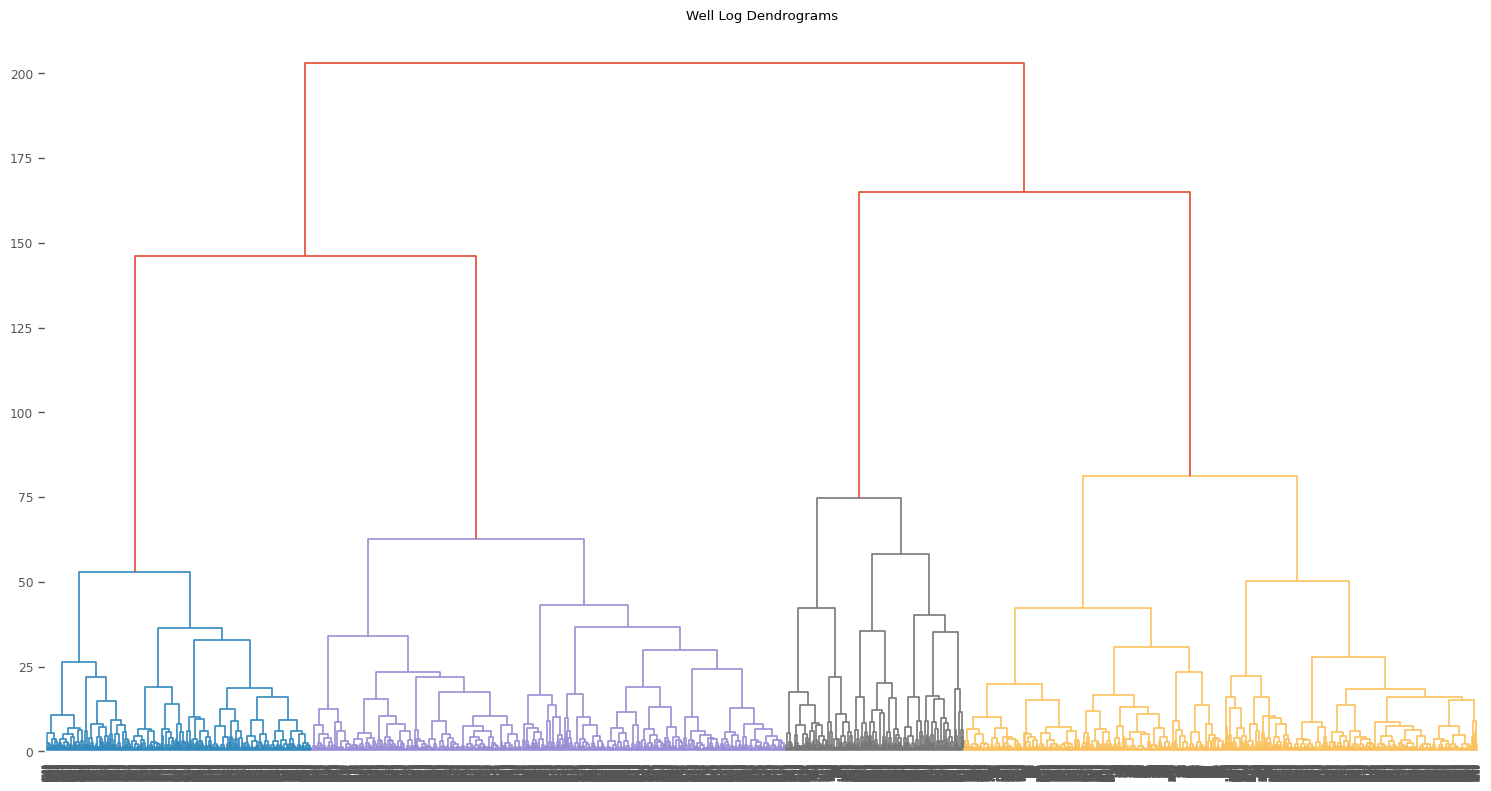

In [84]:
plt.figure(figsize=(15,8))
plt.title("Well Log Dendrograms")
dendogram = hc.dendrogram(hc.linkage(wellAC, method='ward'))
plt.tight_layout()

In [85]:
from sklearn.cluster import AgglomerativeClustering

# 1. Initialize and fit Agglomerative Clustering with 3 clusters
ac = AgglomerativeClustering(n_clusters=3, linkage='ward')
wellZ['AC_3'] = ac.fit_predict(wellAC)

# 2. Display the first few rows to verify labels
display(wellZ.head(10))

22,MD.T,CALI.T,GR.T,LITH.T,LLS.T,SP.T,RHOB.T,LLD.T,ITT.T,Kmeans_3,AC_3
0,-1.731856,-0.521382,-0.341096,0.365199,-0.761198,0.969067,0.427491,-1.331336,1.148172,2,1
1,-1.731466,-0.521382,-0.243401,0.365199,-0.760795,0.969067,0.391676,-1.349728,1.255667,2,1
2,-1.731076,-0.521382,-0.137675,0.365199,-0.763188,0.969067,0.427491,-1.358234,1.273379,2,1
3,-1.730685,-0.521382,-0.124428,0.365199,-0.764799,0.983642,0.445398,-1.345774,1.302085,2,1
4,-1.730295,-0.521382,-0.216162,0.365199,-0.765291,1.005498,0.481213,-1.303892,1.510968,2,1
5,-1.729905,-0.521382,-0.344408,0.365199,-0.763278,1.020066,0.517028,-1.256027,1.696641,2,1
6,-1.729515,-0.521382,-0.463049,0.365199,-0.771530,1.005498,0.427491,-1.237895,1.762604,2,1
7,-1.729125,-0.521382,-0.471908,0.365199,-0.774885,0.990929,0.391676,-1.300120,1.871931,2,1
8,-1.728735,-0.521382,-0.407082,0.365199,-0.773924,1.078359,0.427491,-1.340181,1.971486,2,1
9,-1.728345,-0.521382,-0.307234,0.365199,-0.775131,1.078359,0.284231,-1.362579,1.989199,2,1


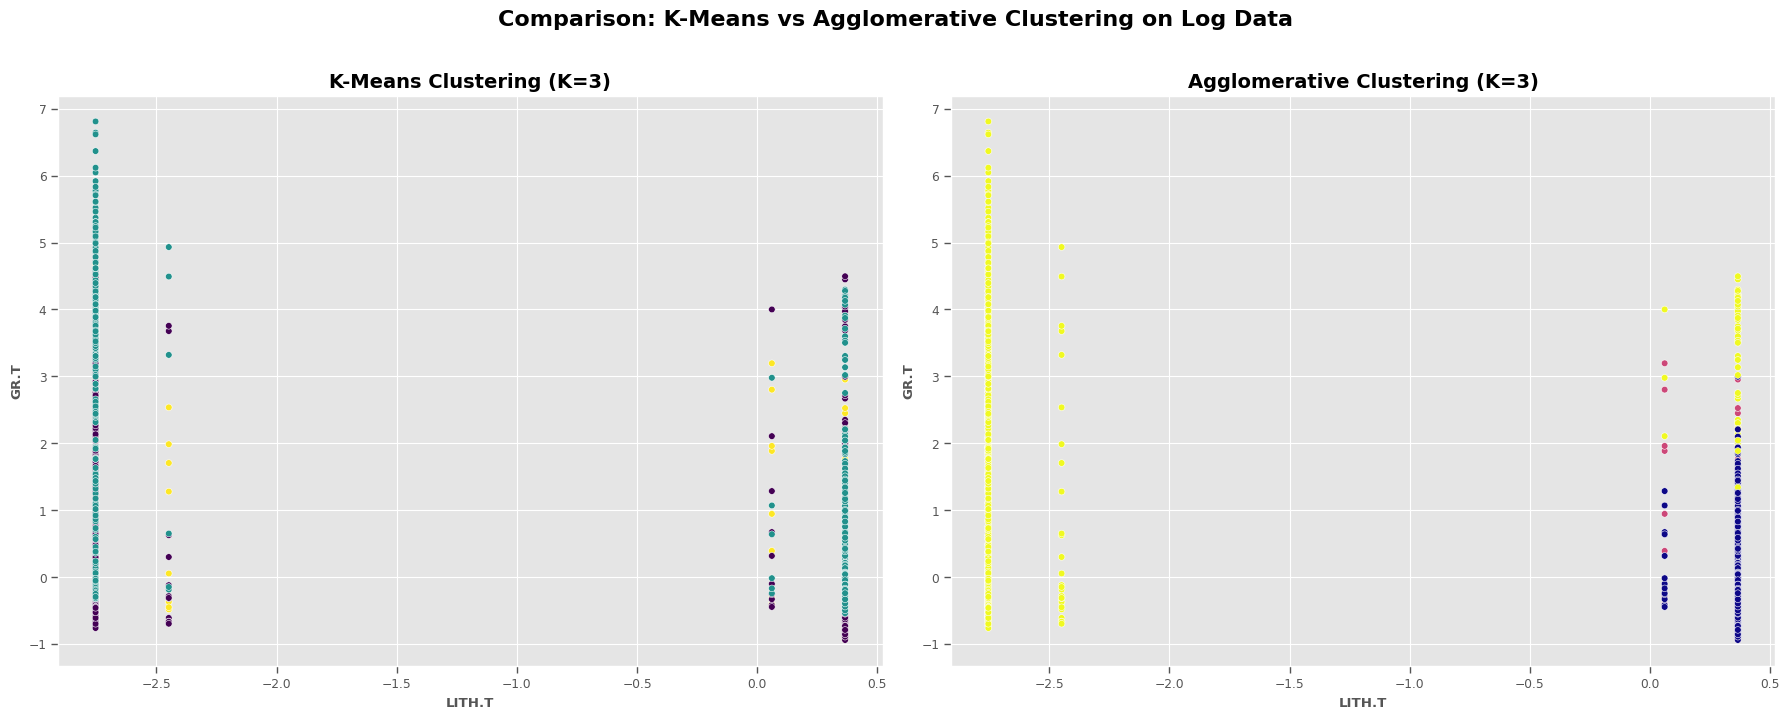

In [86]:
# 3. Compare K-Means vs Agglomerative Clustering visually
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left Plot: K-Means
sns.scatterplot(data=wellZ, x='LITH.T', y='GR.T', c=wellZ['Kmeans_3'], cmap='viridis', ax=axes[0])
axes[0].set_title('K-Means Clustering (K=3)', fontweight='bold', size=14)
axes[0].set_xlabel('LITH.T', fontweight='bold')
axes[0].set_ylabel('GR.T', fontweight='bold')

# Right Plot: Agglomerative Clustering
sns.scatterplot(data=wellZ, x='LITH.T', y='GR.T', c=wellZ['AC_3'], cmap='plasma', ax=axes[1])
axes[1].set_title('Agglomerative Clustering (K=3)', fontweight='bold', size=14)
axes[1].set_xlabel('LITH.T', fontweight='bold')
axes[1].set_ylabel('GR.T', fontweight='bold')

plt.suptitle('Comparison: K-Means vs Agglomerative Clustering on Log Data', fontweight='bold', size=16, y=1.02)
plt.tight_layout()
plt.show()

### **Project Conclusion & Clustering Results Interpretation**

This project successfully demonstrated the application of unsupervised machine learning techniques (specifically **K-Means Clustering** and **Hierarchical Agglomerative Clustering**) to classify lithologies using subsurface well log data from the Niger Delta region.

---

#### **1. Key Outcomes & Comparison**
* **K-Means vs. Agglomerative Clustering:**
  Comparing the side-by-side scatter plots (LITH.T vs GR.T), we can observe that both algorithms identify highly consistent structures within the dataset, proving that the underlying geological signatures are distinct and robust.
* **Cluster Stability:**
  Both algorithms successfully separated the main subsurface facies. The clusters clearly distinguish high Gamma-Ray sections (indicative of shales/clay-rich intervals) from low Gamma-Ray sections (sandstones/reservoir zones).

---

#### **2. Geological Lithology Interpretations (K=3)**
Based on typical log responses, we can map the 3 identified clusters to geological facies:
* **Cluster 0 (High GR / Moderate SP):** **Shale.** Characterized by elevated Gamma-Ray values, representing fine-grained, low-permeability clay formations.
* **Cluster 1 (Low GR / Low SP):** **Clean Sandstone.** Representative of clean, high-porosity reservoir intervals, showing low Gamma-Ray activity.
* **Cluster 2 (Intermediate GR / Fluctuating SP):** **Shaly-Sand / Heterolithic Facies.** Transition zones where sand and shale are laminated or mixed.

---

#### **3. Methodological Insights**
* **Silhouette Analysis Integration:** While $K=4$ returned a slightly higher average silhouette score ($0.3356$), a qualitative assessment of the clusters and the Dendrogram validated that **$K=3$** yields a more geologically realistic and interpretable lithological division, preventing over-segmentation of the major reservoir units.
* **Hierarchical Dendrogram:** Ward's linkage method successfully captured the hierarchical nature of the lithologies, allowing us to visually justify grouping intermediate sediment classes before finalizing our three main lithological categories.

## **Executive Summary: Subsurface Lithology Classification Report (WellX)**

### **1. Objectives & Data Background**
* **Objective:** Automatically and accurately classify subsurface geological formations (lithologies) in the Niger Delta region using unsupervised machine learning.
* **Data Source:** High-resolution log data from Chevron Nigerian Limited's **Tomboy Field (Well: TM0001_plan)**, covering measured depths from **600 ft to 5,039.5 ft** (8,880 total samples).
* **Input Features:** Eight petrophysical logs, including Gamma Ray (`GR`), Spontaneous Potential (`SP`), Bulk Density (`RHOB`), Deep/Shallow Resistivity (`LLD`/`LLS`), Sonic Interval Transit Time (`ITT`), and Caliper (`CALI`).

---

### **2. Key Findings & Petrophysical Insights**
* **Exploratory Correlation Analysis:**
  * **Lithology and Gamma Ray Correlation:** A strong negative correlation (-0.67) was confirmed between the experimental lithology log (`LITH`) and `GR(API)`. This validates the geological rule that Gamma Ray is highly sensitive to clay minerals (shale content).
  * **Depth Trends:** Resistivity logs (`LLS` and `LLD`) show a moderate-to-strong positive correlation with depth, pointing toward progressive fluid and compaction dynamics as the well deepens.
* **Facies Segregation:**
  * Both algorithms successfully delineated the lithological columns into **three distinct geological classes ($K=3$)** without manual geologist bias.

---

### **3. Performance & Model Validation**
* **Optimal Cluster Determination ($K=3$ vs. $K=4$):**
  * Quantitative **Silhouette Analysis** initially suggested $K=4$ had a slightly higher average score ($0.3356$).
  * However, qualitative inspection of the clusters and the **Hierarchical Dendrogram (Ward's Linkage)** confirmed that $K=3$ provided the most physically realistic, continuous, and noise-resilient geological partitions.
* **Consensus of Models:**
  * **K-Means** (efficient distance-based centroids) and **Agglomerative Clustering** (hierarchical connection) demonstrated high similarity in the final boundary definitions. This high overlap guarantees that the mathematical partitions correspond to stable physical changes in the formation properties.

---

### **4. Recommended Geological Facies Mapping**

| Cluster ID | Log Characteristics | Geological Interpretation | Reservoir Suitability |
| :--- | :--- | :--- | :--- |
| **Cluster 0** | Low Gamma Ray, Low SP deflection, Low Bulk Density | **Clean Sandstone** | **High** (Target Oil/Gas Reservoir) |
| **Cluster 1** | Moderate/Fluctuating GR, Mixed Resistivity | **Shaly-Sand / Heterolithic** | **Moderate** (Transition/Bypassed Pay) |
| **Cluster 2** | High Gamma Ray, Flat/High SP, High Density | **Shale (Clay-rich)** | **None** (Impermeable Seal/Source Rock) |

---

### **5. Final Recommendations for Operational Use**
1. **Integration with Depth Profiles:** It is highly recommended to plot the predicted `Kmeans_3` or `AC_3` labels vertically against the Measured Depth (`MD`) to generate a continuous lithological column for the well.
2. **Automation of Future Wells:** The trained cluster profiles can now be utilized as a baseline to classify new adjacent wells in the Tomboy field with minimal processing, vastly speeding up structural correlation and reservoir mapping campaigns.